# 7.0 Data Analysis and Findings
---
---

**We look at findings from all the sections:**
- 1 ETL create staging table fit for further analysis
- 2 Data cleanse - Identificiaton of re-keys, stock control, administrative charges adn such like
- 3 Foundation - customer, Firmographic, Lifecycle / Value, basic, Seasonal, Pareto, trajectory
- 4 Behavioural, shopping patterns --> persona backbone
- 5 Product Affinity
- 6 Triangulation, determine suitable personas from 1 - 4 and define business value
- 7 Validation, testing and business storyline

---
## 3 We look at foundational customer information

#### Load B2B Customer Segmentation Data
---
---

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/processed/B2B_customer_segmentation.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the ETL notebook's 1,2 & 3.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the ETL notebook's 1,2 & 3.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing B2B_customer_segmentation ..")
    df_B2B_customer_segmentation = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe B2B_customer_segmentation complete.")

⏳ Importing B2B_customer_segmentation ..
✅ Data loaded to dataframe B2B_customer_segmentation complete.


In [2]:
# Check column names, data types, and non-null counts
df_B2B_customer_segmentation.info()

<class 'pandas.DataFrame'>
RangeIndex: 5821 entries, 0 to 5820
Data columns (total 76 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   CustomerHashID               5821 non-null   string        
 1   total_n_invoices             5821 non-null   Int64         
 2   total_n_lines                5821 non-null   Int64         
 3   total_n_skus                 5821 non-null   Int64         
 4   total_qty                    5821 non-null   Int64         
 5   total_revenue                5821 non-null   float64       
 6   avg_qty_per_line             5821 non-null   float64       
 7   median_qty_per_line          5821 non-null   float64       
 8   max_qty_per_line             5821 non-null   Int64         
 9   first_purchase               5821 non-null   datetime64[us]
 10  last_purchase                5821 non-null   datetime64[us]
 11  n_countries                  5821 non-null   Int64    

#### Load B2B Customer Orders Data
---
---

In [3]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/processed/B2B_customer_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the ETL notebook's 1,2 & 3.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the ETL notebook's 1,2 & 3.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing B2B_customer_orders ..")
    df_B2B_customer_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe B2B_customer_orders complete.")

⏳ Importing B2B_customer_orders ..
✅ Data loaded to dataframe B2B_customer_orders complete.


In [4]:
# Check column names, data types, and non-null counts
df_B2B_customer_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 783796 entries, 0 to 783795
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Invoice             783796 non-null  str           
 1   StockCode           783796 non-null  str           
 2   Description         783796 non-null  str           
 3   Quantity            783796 non-null  int64         
 4   InvoiceDate         783796 non-null  datetime64[us]
 5   UnitPrice           783796 non-null  float64       
 6   TotalPrice          783796 non-null  float64       
 7   CustomerHashID      783796 non-null  str           
 8   Country             783796 non-null  str           
 9   Cancellation        783796 non-null  bool          
 10  InvoiceDateMin      783796 non-null  datetime64[us]
 11  StockCodeType       783796 non-null  str           
 12  DescriptionType     783796 non-null  str           
 13  WarehouseInventory  0 non-null       str

---
# Table Specifications
---
---

#### **Table name:** B2B_customer_segmentation
- Fields: 48
- Rows: 5,849
- File Size: 1.1 MB
- Approximate Memory Use: 2.8 MB

| **Field** | **Description** | **Data Type** | **Example** |
| :--- | :--- | :--- | :--- |
| CustomerHashID | Pseudonymised customer number | String | 09c72970956ea... |
| n_invoices | Number of invoices | Int64 | 145 |
| n_lines | Number of line items | Int64 | 1056 |
| n_skus | Number of unique stock units | Int64 | 382 |
| total_qty | Total number of products | Int64 | 188060 |
| total_revenue | Total revenue of all purchases | Float64 | 607539.25 |
| ltm_revenue | Last 12 month revenue of purchases | Float64 | 307539.25 |
| avg_qty_per_line | Average number of products per line item | Float64 | 178.0 |
| median_qty_per_line | Median number of products per line item | Float64 | 120.0 |
| max_qty_per_line | Max number of products per line item | Int64 | 1008 |
| first_purchase | First date of purchase | Datetime64 | 2009-12-01 09:24:00 |
| last_purchase | Last date of purchase | Datetime64 | 2011-12-09 11:50:00 |
| n_countries | Number of different countries shipped to | Int64 | 1 |
| avg_basket_breadth | Average number of different products per invoice | Float64 | 7.15 |
| avg_basket_value | Average revenue per basket | Float64 | 4189.9 |
| avg_basket_qty | Average number of items per basket | Float64 | 1296.9 |
| avg_item_value | Average item price = total revenue over quantity | Float64 | 3.90 |
| active_span_days | Days between first and last purchase | Int64 | 738 |
| orders_per_month | Average number of orders per month | Float64 | 5.98 |
| recency_days | Days since last purchase | Int64 | 10 |
| repeat_customer | Flag for returning customers | Boolean | True |
| cohort_month | Month of customer's first purchase | Period(M) | 2010-09 |
| is_left_censored | Flag for customers existing prior to dataset start | Boolean | False |
| pct_case_pack_wholesale| Percentage of items bought in wholesale multiples | Float64 | 0.29 |
| pct_case_pack_metric | Percentage of items bought in metric multiples | Float64 | 0.08 |
| pct_case_pack_total | Total percentage of pack multiples | Float64 | 0.37 |
| pct_business_hours | Percentage of orders made during business hours | Float64 | 0.88 |
| pct_after_hours_wkday | Percentage of orders made during evening hours | Float64 | 0.10 |
| pct_weekend | Percentage of orders made on the weekend | Float64 | 0.02 |
| country_mode | Most frequent country of purchase | String | IRELAND |
| rev_slope | Linear trend of revenue over active months | Float64 | -270.76 |
| rev_slope_pct | Percentage trend of revenue over active months | Float64 | -0.01 |
| n_active_months | Number of distinct months with a purchase | Int64 | 13 |
| region | Broad geographic region | String | APAC |
| sub_region | Specific geographic sub-region | String | OCEANIA |
| R | Recency score (1-5) | Int64 | 5 |
| F | Frequency score (1-5) | Int64 | 4 |
| M | Monetary score (1-5) | Int64 | 5 |
| RFM_score | Combined R + F + M score (Sum) | Int64 | 14 |
| RFM_cell | Combined R + F + M cell (Concatenation) | String | 545 |
| lifecycle_segment | Behavioral customer segmentation | String | Champions |
| hist_cum_rev_pct | Cumulative total revenue percentile | Float64 | 0.37 |
| historical_value_tier | Full Value tier based on 80/20 Pareto rule | String | Key Account |
| curr_cum_rev_pct | Cumulative 12 month revenue percentile | Float64 | 0.83 |
| current_value_tier | Current Value tier based on 80/20 Pareto rule | String | Core Account |
| trajectory | Customer spend momentum (Growing/Stable/Declining) | String | Growing |
| purchase_behaviour | Customer seasonality profile | String | Year-round |
| multiple_year_purchase | Made purchases in more than one calendar year | Boolean | True |

In [5]:
# %pip install jinja2

---
### Domestic / International Market share

,region,total_customer_count,total_customer_pct,ltm_customer_count,ltm_customer_pct,total_revenue,total_revenue_pct,ltm_revenue,ltm_revenue_pct
0,UK DOMESTIC,"5,311",91.24%,"3,875",90.41%,"£13,973,575.66",83.55%,"£6,917,409.58",82.50%
1,EMEA,448,7.70%,373,8.70%,"£2,453,405.50",14.67%,"£1,247,767.38",14.88%
2,APAC,28,0.48%,17,0.40%,"£232,321.48",1.39%,"£189,619.68",2.26%
3,AMER,15,0.26%,8,0.19%,"£13,315.15",0.08%,"£6,954.19",0.08%
4,CHANNEL ISLANDS,13,0.22%,9,0.21%,"£44,155.36",0.26%,"£20,122.57",0.24%
5,UNSPECIFIED,6,0.10%,4,0.09%,"£8,613.65",0.05%,"£2,667.07",0.03%
6,TOTAL,"5,821",100.00%,"4,286",100.00%,"£16,725,386.80",100.00%,"£8,384,540.47",100.00%


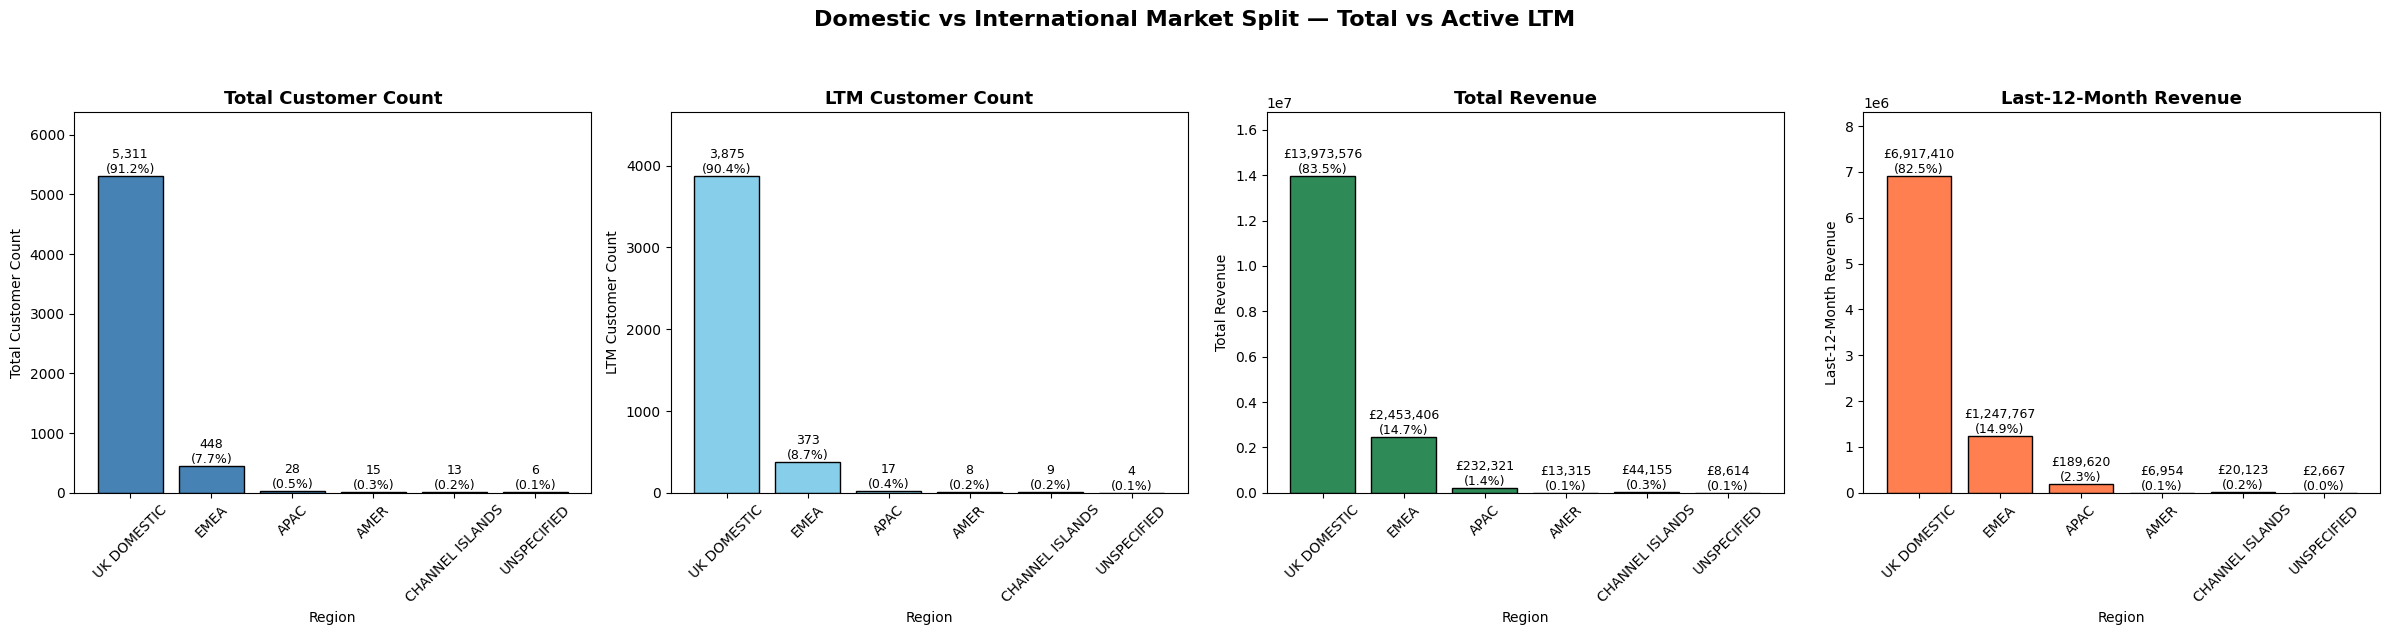

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ---- 1. Aggregate by region -------------------------------------------------
region_summary = (
    df_B2B_customer_segmentation
    .groupby('region', dropna=False)
    .agg(
        total_customer_count    =('CustomerHashID', 'nunique'),
        ltm_customer_count      =('current_year',  'sum'),      # Sums the True values
        total_revenue           =('total_revenue',  'sum'),
        ltm_revenue             =('ltm_revenue',    'sum'),
    )
    .reset_index()
)

# ---- 2. Add percentage columns ---------------------------------------------
region_summary['total_customer_pct']      = region_summary['total_customer_count']     / region_summary['total_customer_count'].sum()     * 100
region_summary['ltm_customer_pct']        = region_summary['ltm_customer_count']       / region_summary['ltm_customer_count'].sum() * 100
region_summary['total_revenue_pct']       = region_summary['total_revenue']            / region_summary['total_revenue'].sum()      * 100
region_summary['ltm_revenue_pct']         = region_summary['ltm_revenue']              / region_summary['ltm_revenue'].sum()        * 100

# Sort by total customer count (largest market first)
region_summary = region_summary.sort_values('total_customer_count', ascending=False).reset_index(drop=True)

# Append a TOTAL row
totals = pd.DataFrame({
    'region':                   ['TOTAL'],
    'total_customer_count':     [region_summary['total_customer_count'].sum()],
    'ltm_customer_count':       [region_summary['ltm_customer_count'].sum()],
    'total_revenue':            [region_summary['total_revenue'].sum()],
    'ltm_revenue':              [region_summary['ltm_revenue'].sum()],
    'total_customer_pct':       [100.0],
    'ltm_customer_pct':         [100.0],
    'total_revenue_pct':        [100.0],
    'ltm_revenue_pct':          [100.0],
})

summary_table = pd.concat([region_summary, totals], ignore_index=True)[
    ['region', 
     'total_customer_count',     'total_customer_pct',
     'ltm_customer_count',       'ltm_customer_pct',
     'total_revenue',            'total_revenue_pct',
     'ltm_revenue',              'ltm_revenue_pct']
]

# ---- 3. Print the table ---------------------------------------------
display(
    summary_table.style
        .format({
            'total_customer_count':     '{:,.0f}',
            'total_customer_pct':       '{:.2f}%',
            'ltm_customer_count':       '{:,.0f}',
            'ltm_customer_pct':         '{:.2f}%',
            'total_revenue':            '£{:,.2f}',
            'total_revenue_pct':        '{:.2f}%',
            'ltm_revenue':              '£{:,.2f}',
            'ltm_revenue_pct':          '{:.2f}%',
        })
        .set_caption("Market split by region — Total vs Active (LTM) Customers & Revenue")
)

# ---- 4. Bar chart ---------------------------------------
plot_df = region_summary.copy()  # exclude total row 

# Changed to 1 row, 4 columns. Widened figsize to 24 to give the bars breathing room.
fig, axes = plt.subplots(1, 4, figsize=(24, 6)) 

metrics = [
    ('total_customer_count',     'total_customer_pct',      'Total Customer Count',  'steelblue', '{:,.0f}'),
    ('ltm_customer_count',       'ltm_customer_pct',        'LTM Customer Count',    'skyblue',   '{:,.0f}'),
    ('total_revenue',            'total_revenue_pct',       'Total Revenue',         'seagreen',  '£{:,.0f}'),
    ('ltm_revenue',              'ltm_revenue_pct',         'Last-12-Month Revenue', 'coral',     '£{:,.0f}'),
]

for ax, (val_col, pct_col, title, color, fmt) in zip(axes, metrics):
    bars = ax.bar(plot_df['region'], plot_df[val_col], color=color, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Region')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)
    ax.margins(y=0.20)  # Added a bit more headroom for the labels
    
    for bar, val, pct in zip(bars, plot_df[val_col], plot_df[pct_col]):
        label = f'{fmt.format(val)}\n({pct:.1f}%)'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Domestic vs International Market Split — Total vs Active LTM', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Key call outs from the above - Last 12 Months
- UK Domestic purchasers make up 90% of the customer base
- EMEA makes up 9%, APAC 1.5%
- Last 12 month revenue looks about half the 2 year total revenue for UK all regions except for APAC and unspecified

**Let's look at Customer Distribution by region versus average of total spend per customer:**

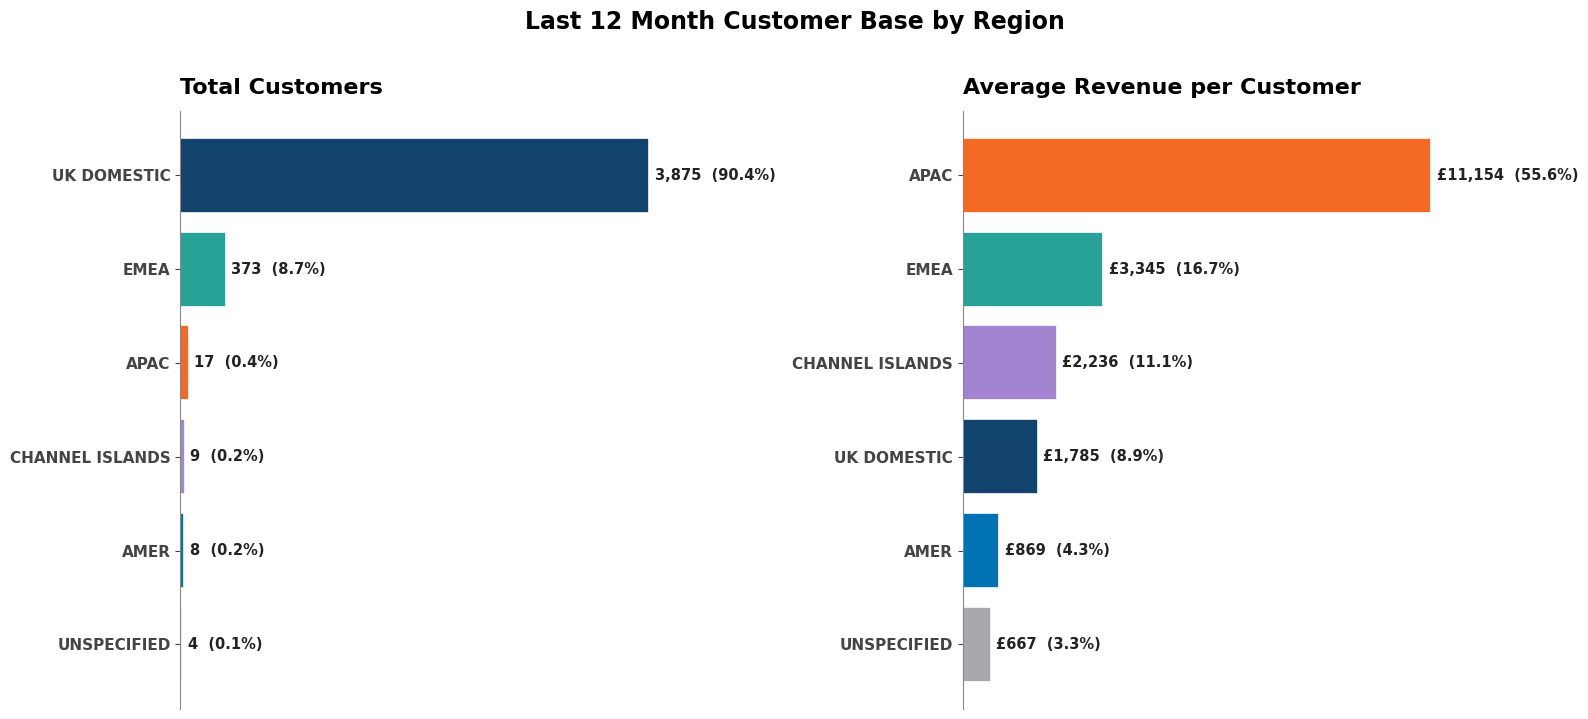

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1. Aggregate -----------------------------------------------------------
region_data = (
    df_B2B_customer_segmentation
    .groupby('region', dropna=False)
    .agg(
        ltm_customer_count      =('current_year',  'sum'),      # Sums the True values
        ltm_revenue             =('ltm_revenue',    'sum'),
    )
    .reset_index()
)
region_data['customer_pct']           = region_data['ltm_customer_count'] / region_data['ltm_customer_count'].sum() * 100
region_data['avg_spend_per_customer'] = region_data['ltm_revenue']  / region_data['ltm_customer_count']
region_data['avg_spend_pct']          = region_data['avg_spend_per_customer']  / region_data['avg_spend_per_customer'].sum() * 100

# ---- 2. Fixed colour per region -------------
palette = {
    'UK DOMESTIC':     '#12436D',  # Dark Blue
    'EMEA':            '#28A197',  # Turquoise
    'APAC':            '#F46A25',  # Orange
    'AMER':            '#0072B2',  # Standard Blue
    'CHANNEL ISLANDS': '#A285D1',  # Light Purple
    'UNSPECIFIED':     '#A7A9AC',  # Light Grey
}
region_data['colour'] = region_data['region'].map(lambda r: palette.get(r, '#607D8B'))

# Each panel sorted independently — ascending=True puts the largest value at the TOP of a horizontal bar chart
left_df  = region_data.sort_values('ltm_customer_count',         ascending=True)
right_df = region_data.sort_values('avg_spend_per_customer',     ascending=True)

# ---- 3. Plot ----------------------------------------------------------------
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Last 12 Month Customer Base by Region',
             fontsize=17, fontweight='bold', y=1.02)

def style_axis(ax, xfmt):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False) 
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    # ax.grid(axis='x', linestyle=':', alpha=0.5)
    # ax.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444')
    ax.tick_params(axis='x', bottom=False, labelbottom=False)  
    ax.xaxis.set_major_formatter(plt.FuncFormatter(xfmt))
    
# LEFT — customer volume
max_customers = left_df['ltm_customer_count'].max()

# We coud not see APAC -> Unspecified on left graph due to 90% UK Domestic
# I stretch them by a slither to make visible
small_bar_multiplier = 4 

# List of the specific regions you want to stretch
regions_to_boost = ['APAC', 'CHANNEL ISLANDS', 'AMER', 'UNSPECIFIED']

# Create the adjusted widths for the graph
plot_widths = []
for region, val in zip(left_df['region'], left_df['ltm_customer_count']):
    if region in regions_to_boost:
        plot_widths.append(val * small_bar_multiplier)
    else:
        plot_widths.append(val)

# Plot the bars using the artificially stretched widths
bars_l = ax_l.barh(left_df['region'], plot_widths,
                   color=left_df['colour'], edgecolor='white', linewidth=1.2)

ax_l.set_title('Total Customers', fontsize=16, fontweight='bold', pad=12, loc='left')
ax_l.set_xlim(0, max_customers * 1.22)
style_axis(ax_l, lambda x, _: f'{int(x):,}')

# Add the text labels using the TRUE data values
for bar, true_count, pct in zip(bars_l, left_df['ltm_customer_count'], left_df['customer_pct']):
    
    # We use bar.get_width() to place the text
    # We print the 'true_count' so the label references ltm_customer_count
    ax_l.text(bar.get_width() + max_customers * 0.012,
              bar.get_y() + bar.get_height()/2,
              f'{true_count:,}  ({pct:.1f}%)',
              va='center', ha='left', fontsize=10.5, fontweight='bold', color='#222222')

# RIGHT — average revenue per customer
bars_r = ax_r.barh(right_df['region'], right_df['avg_spend_per_customer'],
                   color=right_df['colour'], edgecolor='white', linewidth=1.2)
ax_r.set_title('Average Revenue per Customer', fontsize=16, fontweight='bold', pad=12, loc='left')
# ax_r.set_xlabel('Average Revenue per Customer (£)', fontsize=11)
ax_r.set_xlim(0, right_df['avg_spend_per_customer'].max() * 1.22)
style_axis(ax_r, lambda x, _: f'£{int(x):,}')
# for bar, val in zip(bars_r, right_df['avg_spend_per_customer']):
#     ax_r.text(bar.get_width() + right_df['avg_spend_per_customer'].max() * 0.012,
#               bar.get_y() + bar.get_height()/2,
#               f'£{val:,.0f}',
#               va='center', ha='left', fontsize=10.5, fontweight='bold', color='#222222')
    
for bar, val, pct in zip(bars_r,
                         right_df['avg_spend_per_customer'],
                         right_df['avg_spend_pct']):
    ax_r.text(bar.get_width() + right_df['avg_spend_per_customer'].max() * 0.012,
              bar.get_y() + bar.get_height()/2,
              f'£{val:,.0f}  ({pct:.1f}%)',
              va='center', ha='left', fontsize=10.5, fontweight='bold', color='#222222')

plt.setp(ax_l.get_yticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax_r.get_yticklabels(), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
# Key Graph - 1
Looks at regional distribution and spend of B2B customers in the last 12 months:
- UK Domestic makes up 90% of the customer base and 83% of total revenue with EMEA making up 9% share and 15% of the revenue
- In terms of average spend, APAC and EMEA make up a combined 72% of the spend per customer with APAC on £11.2k versus £2.2k UK Domestic 

*NB this is a product only view which excludes returns, re-keys, postage fees, additional charges and such like.*


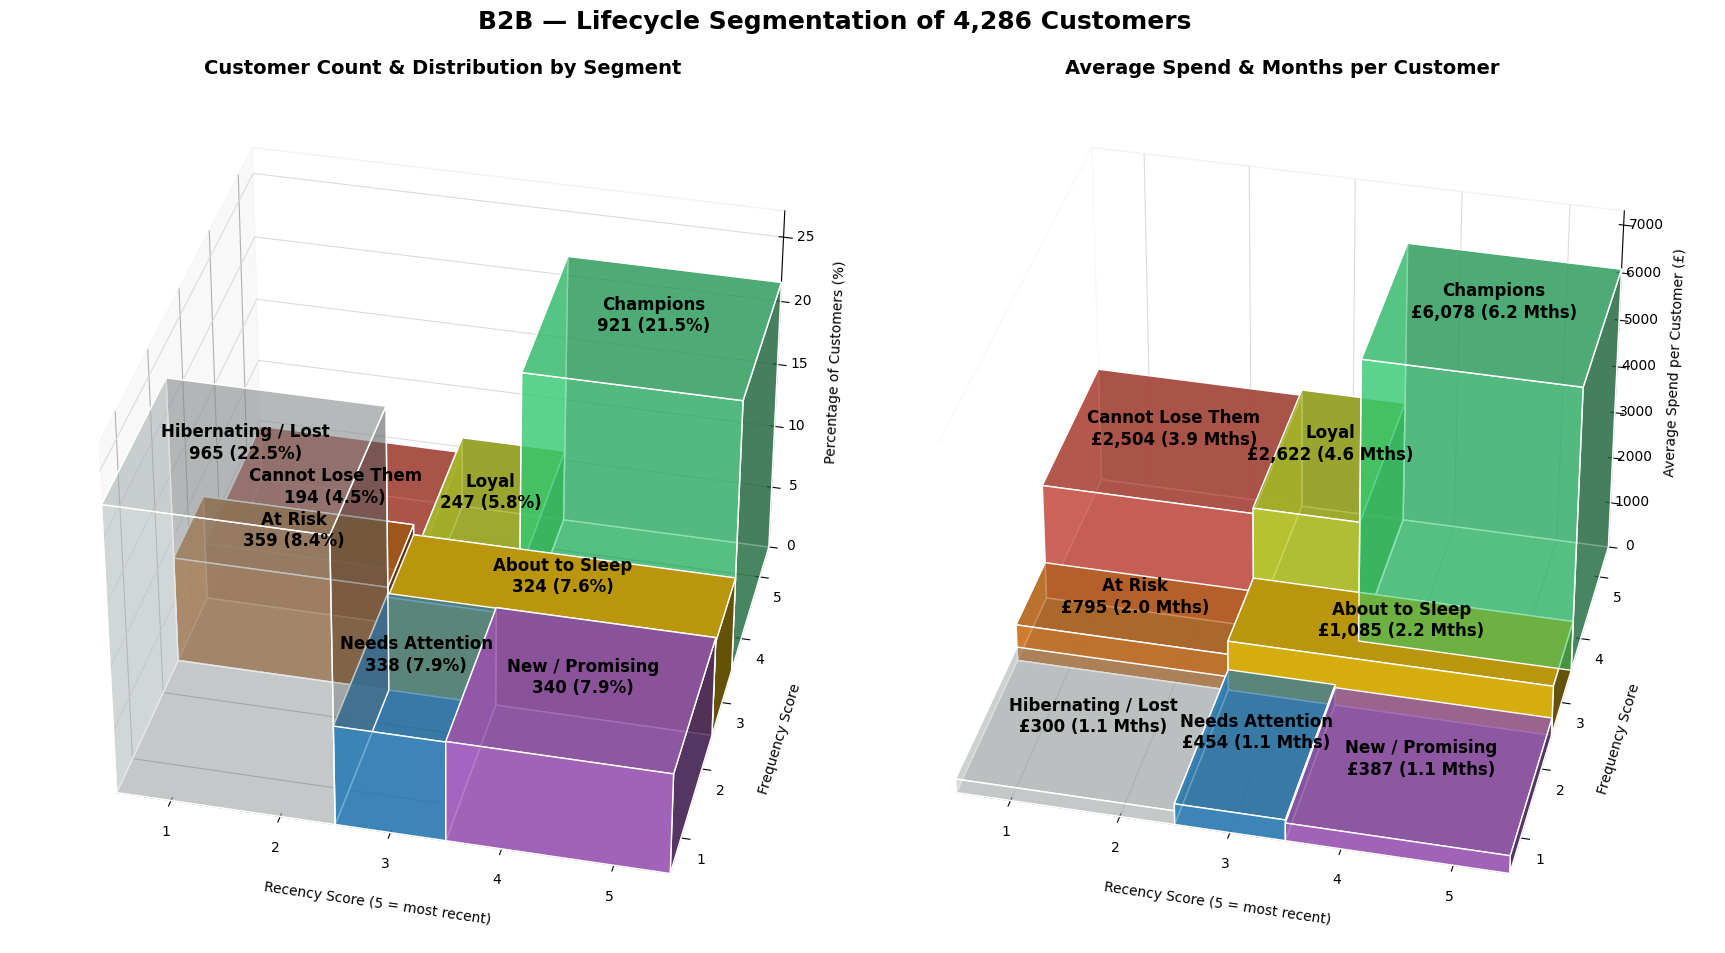

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors


# ---- 1. Aggregations -------------------------------------------------------
seg_counts      = df_B2B_customer_segmentation.groupby('lifecycle_segment')['current_year'].sum()
seg_avg_spend   = df_B2B_customer_segmentation.groupby('lifecycle_segment')['ltm_revenue'].mean()
total_customers = int(seg_counts.sum())
seg_active_mths = df_B2B_customer_segmentation.groupby('lifecycle_segment')['ltm_n_active_months'].mean()

# ---- 2. Colour / alpha / layout maps (unchanged) ---------------------------
colour_map = {
    'Champions':          '#36e47f',
    'Loyal':              '#d3e436',
    'Cannot Lose Them':   '#e76f62',
    'At Risk':            '#e67e22',
    'Needs Attention':    '#3498db',
    'About to Sleep':     '#f1c40f',
    'Hibernating / Lost': '#ced7d7',
    'New / Promising':    '#bd72da',
    'Frequent Low-Spend': '#9b59b6',
}

alpha_map = {
    'Hibernating / Lost':     0.35,
    'Champions':              0.55,
    'At Risk':                0.70,
    'Needs Attention':        0.70,
    'Loyal':                  0.80,
    'New / Promising':        0.85,
    'Cannot Lose Them':       0.90,
    'About to Sleep':         1.00,
}

segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),
    'Loyal':              (2, 3, 1, 2),
    'Champions':          (3, 3, 2, 2),
    'At Risk':            (0, 2, 2, 1),
    'About to Sleep':     (2, 2, 3, 1),
    'Hibernating / Lost': (0, 0, 2, 2),
    'Needs Attention':    (2, 0, 1, 2),
    'New / Promising':    (3, 0, 2, 2),
}

# ---- 3. Helper: draw one 3D RFM chart on a given axis ----------------------
def draw_rfm_3d(ax, metric_dict, label_builder, z_label, title):
    x_pos, y_pos, z_pos = [], [], []
    dx, dy, dz = [], [], []
    colors = []
    max_val = max(metric_dict.values()) if metric_dict else 0

    for seg, (x, y, w, h) in segment_boxes.items():
        val = metric_dict.get(seg, 0)

        x_pos.append(x);  y_pos.append(y);  z_pos.append(0)
        dx.append(w);     dy.append(h);     dz.append(val)

        rgba = mcolors.to_rgba(colour_map.get(seg, '#333333'),
                               alpha_map.get(seg, 0.8))
        colors.append(rgba)

        # Floating label — offset scaled to the metric so it works for % AND £
        ax.text(x + w/2, y + h/2, val + max_val * 0.04,
                label_builder(seg, val),
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black',
                linespacing=1.25 )

    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz,
             color=colors, edgecolor='white', shade=True)

    ax.set_xlim(0, 5);  ax.set_ylim(0, 5)
    ax.set_zlim(0, max_val * 1.20)
    ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'])
    ax.set_yticklabels(['1', '2', '3', '4', '5'])
    ax.set_xlabel('\nRecency Score (5 = most recent)',  fontsize=10, linespacing=3)
    ax.set_ylabel('\nFrequency Score', fontsize=10, linespacing=3)
    ax.set_zlabel(z_label, fontsize=10, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=0)
    ax.view_init(elev=35, azim=-77)

# ---- 4. Two 3D panels side-by-side -----------------------------------------
fig = plt.figure(figsize=(22, 11))
fig.suptitle(f'B2B — Lifecycle Segmentation of {total_customers:,} Customers',
             fontsize=18, fontweight='bold', y=0.96)

ax_left  = fig.add_subplot(1, 2, 1, projection='3d')
ax_right = fig.add_subplot(1, 2, 2, projection='3d')

# Clean up panes and grid on the left chart
# ax_left.xaxis.pane.fill = False   # side wall gone
ax_left.zaxis.pane.fill = False   # floor gone
ax_left.yaxis.pane.fill = False   # floor gone

# Gridlines 
# ax_left.yaxis._axinfo['grid']['linewidth'] = 0
# ax_left.zaxis._axinfo['grid']['linewidth'] = 0
ax_left.xaxis._axinfo['grid']['linewidth'] = 0

ax_left.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_left.zaxis._axinfo['grid']['color'] = '#dbdbdb'

# LEFT — Total customers and percentage
pct_dict = {seg: (seg_counts.get(seg, 0) / total_customers) * 100
            for seg in segment_boxes}
draw_rfm_3d(
    ax_left,
    metric_dict=pct_dict,
    label_builder=lambda seg, v: f"{seg}\n{int(seg_counts.get(seg, 0)):,} ({v:.1f}%)",
    z_label='Percentage of Customers (%)',
    title='Customer Count & Distribution by Segment',
)

# Clean up panes and grid on the right chart
ax_right.xaxis.pane.fill = False   # side wall gone
ax_right.zaxis.pane.fill = False   # floor gone
ax_right.yaxis.pane.fill = False   # floor gone

# Gridlines 
ax_right.yaxis._axinfo['grid']['linewidth'] = 0
ax_right.zaxis._axinfo['grid']['linewidth'] = 0
# ax_right.xaxis._axinfo['grid']['linewidth'] = 0

ax_right.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_right.zaxis._axinfo['grid']['color'] = '#dbdbdb'


# RIGHT — average spend per customer
avg_spend_dict = {seg: seg_avg_spend.get(seg, 0) for seg in segment_boxes}
draw_rfm_3d(
    ax_right,
    metric_dict=avg_spend_dict,
    label_builder=lambda seg, v: f"{seg}\n£{v:,.0f} ({seg_active_mths.get(seg, 0):.1f} Mths)",
    z_label='Average Spend per Customer (£)',
    title='Average Spend & Months per Customer',
)

plt.subplots_adjust(top=0.90, wspace=-0.03)
plt.show()

In [9]:
import pandas as pd

# 1. Group by lifecycle_segment and calculate total customers and total revenue
summary_table = df_B2B_customer_segmentation.groupby('lifecycle_segment').agg(
    Total_Customers=('current_year',  'sum'), # Count unique customers
    Average_Active_Mths=('ltm_n_active_months', 'mean'), # Average of active months
    Total_Revenue=('ltm_revenue', 'sum')         # Sum the total revenue
).reset_index()

# 2. Calculate Total Revenue / Total Customers
summary_table['Revenue_per_Customer'] = summary_table['Total_Revenue'] / summary_table['Total_Customers']

# 3. Rename columns
summary_table.columns = ['Lifecycle Segment', 'Total Customers', 'Average Active Months', 'Total Revenue Spend', 'Total Revenue / Customers']

# Optional: Sort the table by Total Revenue (Highest to Lowest)
summary_table = summary_table.sort_values(by='Total Revenue Spend', ascending=False)

# 4. Display the table with formatting
summary_table.style.format({
    'Total Customers': '{:,.0f}',
    'Average Active Months': '{:,.1f}',
    'Total Revenue Spend': '£{:,.2f}',
    'Total Revenue / Customers': '£{:,.2f}'
})

,Lifecycle Segment,Total Customers,Average Active Months,Total Revenue Spend,Total Revenue / Customers
4,Champions,921,6.2,"£5,597,855.51","£6,078.02"
9,Loyal,247,4.6,"£647,726.08","£2,622.37"
3,Cannot Lose Them,194,3.9,"£485,739.95","£2,503.81"
0,About to Sleep,324,2.2,"£351,475.98","£1,084.80"
7,Hibernating / Lost,965,1.1,"£289,198.36",£299.69
1,At Risk,359,2.0,"£285,410.61",£795.02
8,Lost High-Value,72,1.2,"£162,643.69","£2,258.94"
11,Needs Attention,338,1.1,"£153,373.88",£453.77
12,New / Promising,340,1.1,"£131,678.09",£387.29
5,Champions Lower-Value,137,3.4,"£100,623.31",£734.48


---
# Key Graph - 2
- UK Domestic makes up 90% of the customer base and 83% of total revenue with EMEA making up 8% share and 14% total revenue
- In terms of average spend, APAC and EMEA make up a combined 62% of the spend per customer with APAC on £8.2k versus £2.7k UK Domestic

*NB this is a product only view which excludes returns, re-keys, postage fees, additional charges and such like.*


---
### We look at UK Domestic only:

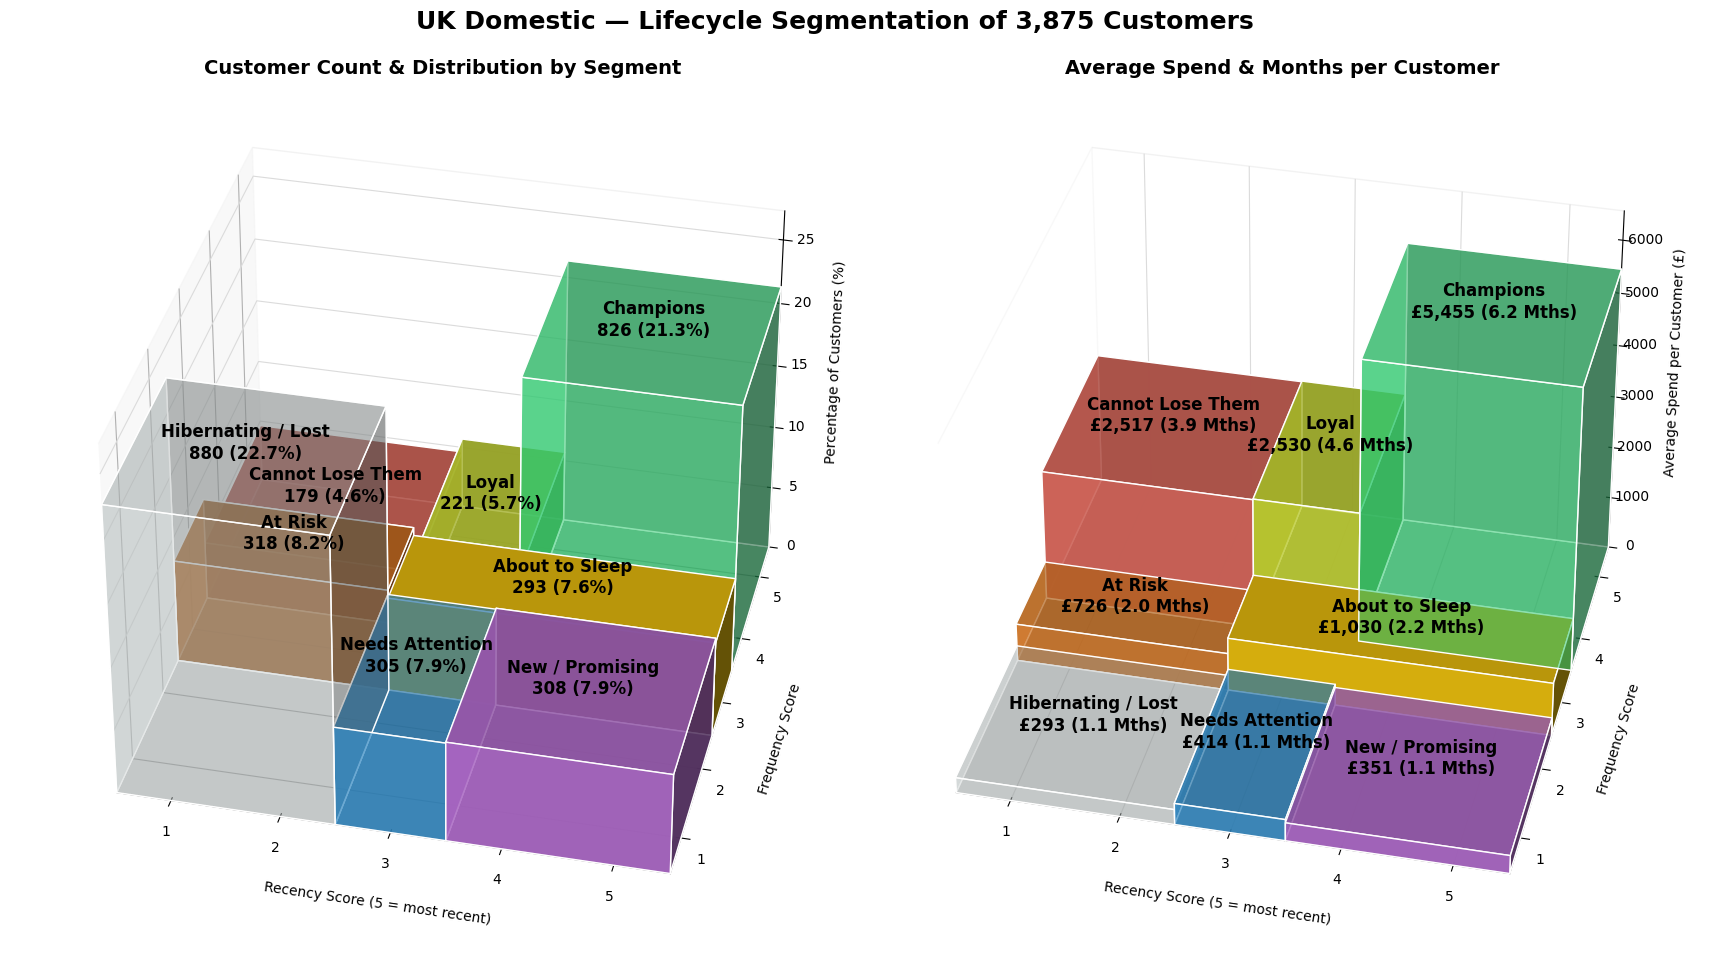

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors


# 0. Create the filtered DataFrame
df_uk = df_B2B_customer_segmentation[df_B2B_customer_segmentation['country_mode'] == 'UNITED KINGDOM']

# ---- 1. Aggregations -------------------------------------------------------
seg_counts      = df_uk.groupby('lifecycle_segment')['current_year'].sum()
seg_avg_spend   = df_uk.groupby('lifecycle_segment')['ltm_revenue'].mean()
total_customers = int(seg_counts.sum())
seg_active_mths = df_uk.groupby('lifecycle_segment')['ltm_n_active_months'].mean()

# ---- 2. Colour / alpha / layout maps (unchanged) ---------------------------
colour_map = {
    'Champions':          '#36e47f',
    'Loyal':              '#d3e436',
    'Cannot Lose Them':   '#e76f62',
    'At Risk':            '#e67e22',
    'Needs Attention':    '#3498db',
    'About to Sleep':     '#f1c40f',
    'Hibernating / Lost': '#ced7d7',
    'New / Promising':    '#bd72da',
    'Frequent Low-Spend': '#9b59b6',
}

alpha_map = {
    'Hibernating / Lost':     0.35,
    'Champions':              0.55,
    'At Risk':                0.70,
    'Needs Attention':        0.70,
    'Loyal':                  0.80,
    'New / Promising':        0.85,
    'Cannot Lose Them':       0.90,
    'About to Sleep':         1.00,
}

segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),
    'Loyal':              (2, 3, 1, 2),
    'Champions':          (3, 3, 2, 2),
    'At Risk':            (0, 2, 2, 1),
    'About to Sleep':     (2, 2, 3, 1),
    'Hibernating / Lost': (0, 0, 2, 2),
    'Needs Attention':    (2, 0, 1, 2),
    'New / Promising':    (3, 0, 2, 2),
}

# ---- 3. Helper: draw one 3D RFM chart on a given axis ----------------------
def draw_rfm_3d(ax, metric_dict, label_builder, z_label, title):
    x_pos, y_pos, z_pos = [], [], []
    dx, dy, dz = [], [], []
    colors = []
    max_val = max(metric_dict.values()) if metric_dict else 0

    for seg, (x, y, w, h) in segment_boxes.items():
        val = metric_dict.get(seg, 0)

        x_pos.append(x);  y_pos.append(y);  z_pos.append(0)
        dx.append(w);     dy.append(h);     dz.append(val)

        rgba = mcolors.to_rgba(colour_map.get(seg, '#333333'),
                               alpha_map.get(seg, 0.8))
        colors.append(rgba)

        # Floating label — offset scaled to the metric so it works for % AND £
        ax.text(x + w/2, y + h/2, val + max_val * 0.04,
                label_builder(seg, val),
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black',
                linespacing=1.25 )

    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz,
             color=colors, edgecolor='white', shade=True)

    ax.set_xlim(0, 5);  ax.set_ylim(0, 5)
    ax.set_zlim(0, max_val * 1.20)
    ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'])
    ax.set_yticklabels(['1', '2', '3', '4', '5'])
    ax.set_xlabel('\nRecency Score (5 = most recent)',  fontsize=10, linespacing=3)
    ax.set_ylabel('\nFrequency Score', fontsize=10, linespacing=3)
    ax.set_zlabel(z_label, fontsize=10, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=0)
    ax.view_init(elev=35, azim=-77)

# ---- 4. Two 3D panels side-by-side -----------------------------------------
fig = plt.figure(figsize=(22, 11))
fig.suptitle(f'UK Domestic — Lifecycle Segmentation of {total_customers:,} Customers',
             fontsize=18, fontweight='bold', y=0.96)

ax_left  = fig.add_subplot(1, 2, 1, projection='3d')
ax_right = fig.add_subplot(1, 2, 2, projection='3d')

# Clean up panes and grid on the left chart
# ax_left.xaxis.pane.fill = False   # side wall gone
ax_left.zaxis.pane.fill = False   # floor gone
ax_left.yaxis.pane.fill = False   # floor gone

# Gridlines 
# ax_left.yaxis._axinfo['grid']['linewidth'] = 0
# ax_left.zaxis._axinfo['grid']['linewidth'] = 0
ax_left.xaxis._axinfo['grid']['linewidth'] = 0

ax_left.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_left.zaxis._axinfo['grid']['color'] = '#dbdbdb'

# LEFT — Total customers and percentage
pct_dict = {seg: (seg_counts.get(seg, 0) / total_customers) * 100
            for seg in segment_boxes}
draw_rfm_3d(
    ax_left,
    metric_dict=pct_dict,
    label_builder=lambda seg, v: f"{seg}\n{int(seg_counts.get(seg, 0)):,} ({v:.1f}%)",
    z_label='Percentage of Customers (%)',
    title='Customer Count & Distribution by Segment',
)

# Clean up panes and grid on the right chart
ax_right.xaxis.pane.fill = False   # side wall gone
ax_right.zaxis.pane.fill = False   # floor gone
ax_right.yaxis.pane.fill = False   # floor gone

# Gridlines 
ax_right.yaxis._axinfo['grid']['linewidth'] = 0
ax_right.zaxis._axinfo['grid']['linewidth'] = 0
# ax_right.xaxis._axinfo['grid']['linewidth'] = 0

ax_right.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_right.zaxis._axinfo['grid']['color'] = '#dbdbdb'


# RIGHT — average spend per customer
avg_spend_dict = {seg: seg_avg_spend.get(seg, 0) for seg in segment_boxes}
draw_rfm_3d(
    ax_right,
    metric_dict=avg_spend_dict,
    label_builder=lambda seg, v: f"{seg}\n£{v:,.0f} ({seg_active_mths.get(seg, 0):.1f} Mths)",
    z_label='Average Spend per Customer (£)',
    title='Average Spend & Months per Customer',
)

# plt.subplots_adjust(top=0.90, wspace=0.05)
plt.subplots_adjust(top=0.90, wspace=-0.03)
plt.show()

---
### We look at EMEA only:

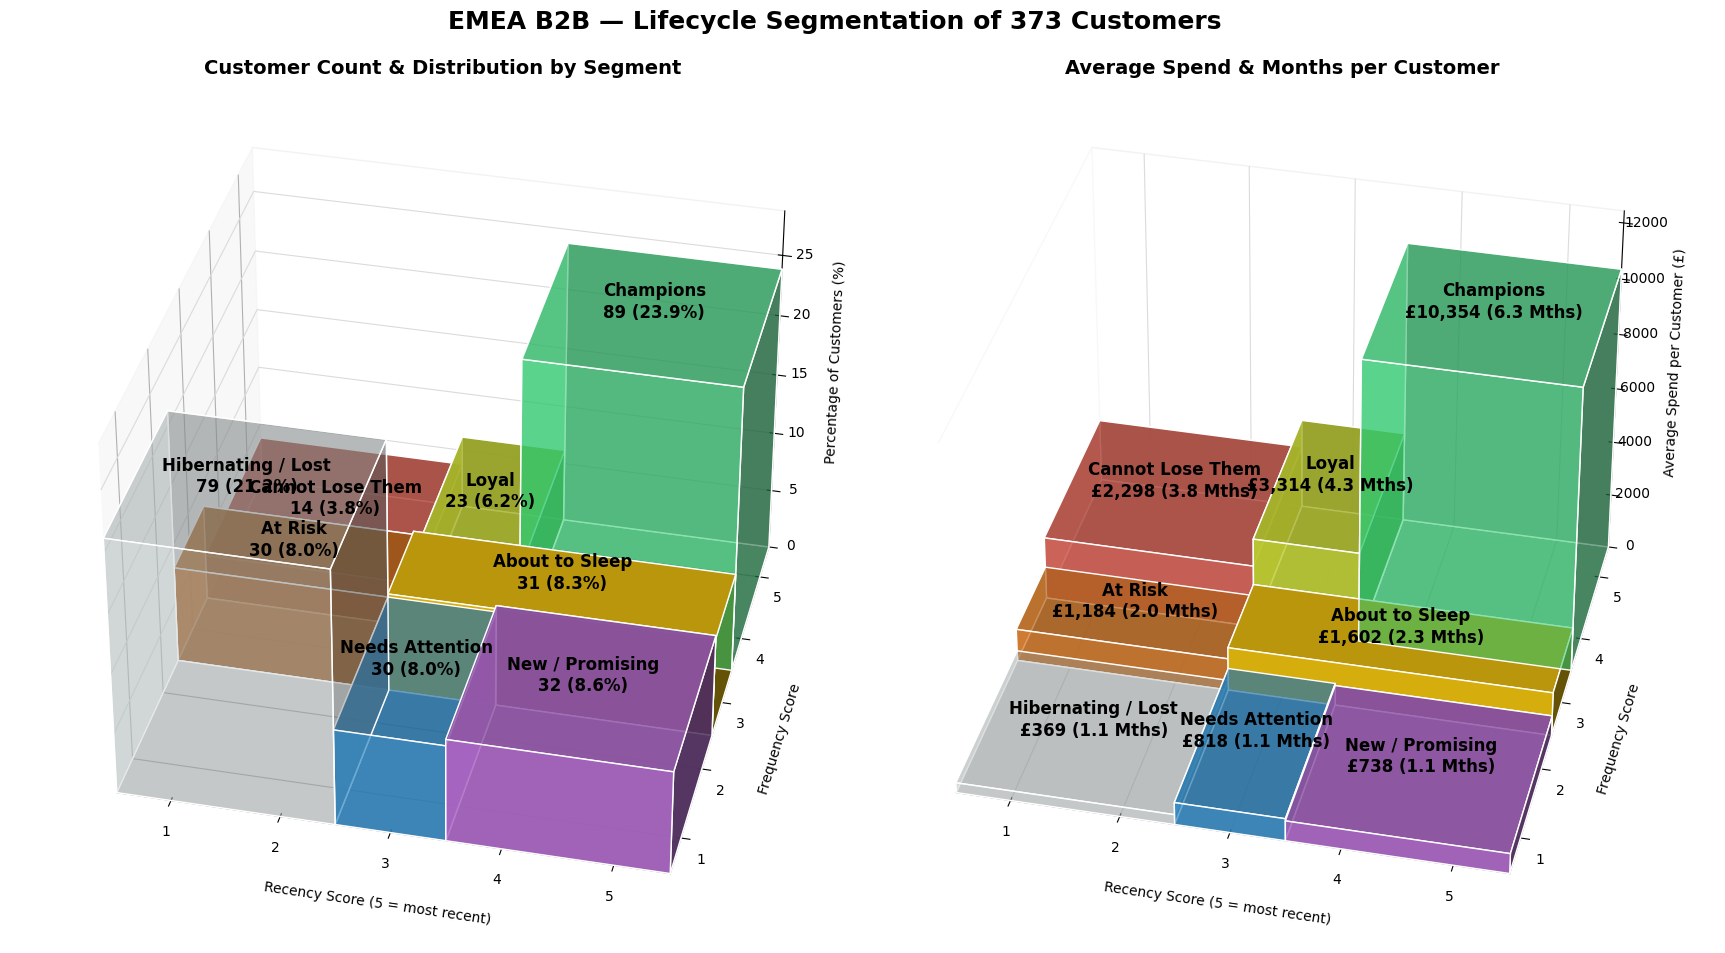

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors


# 0. Create the filtered DataFrame
df_emea = df_B2B_customer_segmentation[df_B2B_customer_segmentation['region'] == 'EMEA']

# ---- 1. Aggregations -------------------------------------------------------
seg_counts      = df_emea.groupby('lifecycle_segment')['current_year'].sum()
seg_avg_spend   = df_emea.groupby('lifecycle_segment')['ltm_revenue'].mean()
total_customers = int(seg_counts.sum())
seg_active_mths = df_emea.groupby('lifecycle_segment')['ltm_n_active_months'].mean()

# ---- 2. Colour / alpha / layout maps (unchanged) ---------------------------
colour_map = {
    'Champions':          '#36e47f',
    'Loyal':              '#d3e436',
    'Cannot Lose Them':   '#e76f62',
    'At Risk':            '#e67e22',
    'Needs Attention':    '#3498db',
    'About to Sleep':     '#f1c40f',
    'Hibernating / Lost': '#ced7d7',
    'New / Promising':    '#bd72da',
    'Frequent Low-Spend': '#9b59b6',
}

alpha_map = {
    'Hibernating / Lost':     0.35,
    'Champions':              0.55,
    'At Risk':                0.70,
    'Needs Attention':        0.70,
    'Loyal':                  0.80,
    'New / Promising':        0.85,
    'Cannot Lose Them':       0.90,
    'About to Sleep':         1.00,
}

segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),
    'Loyal':              (2, 3, 1, 2),
    'Champions':          (3, 3, 2, 2),
    'At Risk':            (0, 2, 2, 1),
    'About to Sleep':     (2, 2, 3, 1),
    'Hibernating / Lost': (0, 0, 2, 2),
    'Needs Attention':    (2, 0, 1, 2),
    'New / Promising':    (3, 0, 2, 2),
}

# ---- 3. Helper: draw one 3D RFM chart on a given axis ----------------------
def draw_rfm_3d(ax, metric_dict, label_builder, z_label, title):
    x_pos, y_pos, z_pos = [], [], []
    dx, dy, dz = [], [], []
    colors = []
    max_val = max(metric_dict.values()) if metric_dict else 0

    for seg, (x, y, w, h) in segment_boxes.items():
        val = metric_dict.get(seg, 0)

        x_pos.append(x);  y_pos.append(y);  z_pos.append(0)
        dx.append(w);     dy.append(h);     dz.append(val)

        rgba = mcolors.to_rgba(colour_map.get(seg, '#333333'),
                               alpha_map.get(seg, 0.8))
        colors.append(rgba)

        # Floating label — offset scaled to the metric so it works for % AND £
        ax.text(x + w/2, y + h/2, val + max_val * 0.04,
                label_builder(seg, val),
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black',
                linespacing=1.25 )

    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz,
             color=colors, edgecolor='white', shade=True)

    ax.set_xlim(0, 5);  ax.set_ylim(0, 5)
    ax.set_zlim(0, max_val * 1.20)
    ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'])
    ax.set_yticklabels(['1', '2', '3', '4', '5'])
    ax.set_xlabel('\nRecency Score (5 = most recent)',  fontsize=10, linespacing=3)
    ax.set_ylabel('\nFrequency Score', fontsize=10, linespacing=3)
    ax.set_zlabel(z_label, fontsize=10, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=0)
    ax.view_init(elev=35, azim=-77)

# ---- 4. Two 3D panels side-by-side -----------------------------------------
fig = plt.figure(figsize=(22, 11))
fig.suptitle(f'EMEA B2B — Lifecycle Segmentation of {total_customers:,} Customers',
             fontsize=18, fontweight='bold', y=0.96)

ax_left  = fig.add_subplot(1, 2, 1, projection='3d')
ax_right = fig.add_subplot(1, 2, 2, projection='3d')

# Clean up panes and grid on the left chart
# ax_left.xaxis.pane.fill = False   # side wall gone
ax_left.zaxis.pane.fill = False   # floor gone
ax_left.yaxis.pane.fill = False   # floor gone

# Gridlines 
# ax_left.yaxis._axinfo['grid']['linewidth'] = 0
# ax_left.zaxis._axinfo['grid']['linewidth'] = 0
ax_left.xaxis._axinfo['grid']['linewidth'] = 0

ax_left.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_left.zaxis._axinfo['grid']['color'] = '#dbdbdb'

# LEFT — Total customers and percentage
pct_dict = {seg: (seg_counts.get(seg, 0) / total_customers) * 100
            for seg in segment_boxes}
draw_rfm_3d(
    ax_left,
    metric_dict=pct_dict,
    label_builder=lambda seg, v: f"{seg}\n{int(seg_counts.get(seg, 0)):,} ({v:.1f}%)",
    z_label='Percentage of Customers (%)',
    title='Customer Count & Distribution by Segment',
)

# Clean up panes and grid on the right chart
ax_right.xaxis.pane.fill = False   # side wall gone
ax_right.zaxis.pane.fill = False   # floor gone
ax_right.yaxis.pane.fill = False   # floor gone

# Gridlines 
ax_right.yaxis._axinfo['grid']['linewidth'] = 0
ax_right.zaxis._axinfo['grid']['linewidth'] = 0
# ax_right.xaxis._axinfo['grid']['linewidth'] = 0

ax_right.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_right.zaxis._axinfo['grid']['color'] = '#dbdbdb'


# RIGHT — average spend per customer
avg_spend_dict = {seg: seg_avg_spend.get(seg, 0) for seg in segment_boxes}
draw_rfm_3d(
    ax_right,
    metric_dict=avg_spend_dict,
    label_builder=lambda seg, v: f"{seg}\n£{v:,.0f} ({seg_active_mths.get(seg, 0):.1f} Mths)",
    z_label='Average Spend per Customer (£)',
    title='Average Spend & Months per Customer',
)

# plt.subplots_adjust(top=0.90, wspace=0.05)
plt.subplots_adjust(top=0.90, wspace=-0.03)
plt.show()

---
### Commercial Value and Basket Share

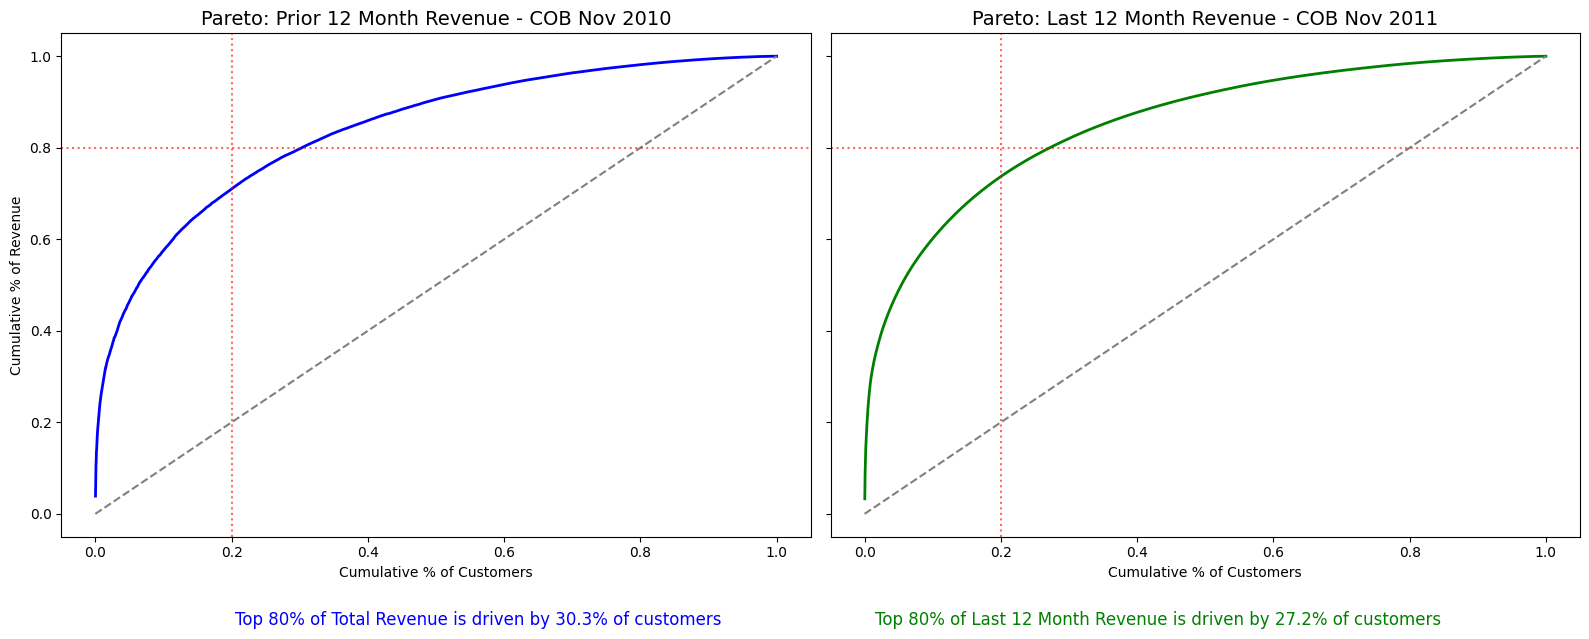

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 0. Create the filtered DataFrame's
df_ftm = df_B2B_customer_segmentation[df_B2B_customer_segmentation['prior_year'] == True]
df_ltm = df_B2B_customer_segmentation[df_B2B_customer_segmentation['current_year'] == True]

# 1. Prepare data for Prior Year Revenue
df_tot = df_ftm.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_tot['cum_rev_pct'] = df_tot['ftm_revenue'].cumsum() / df_tot['ftm_revenue'].sum()
df_tot['cum_cust_pct'] = (df_tot.index + 1) / len(df_tot)

# 2. Prepare data for Current Year Revenue
df_ann = df_ltm.sort_values('ltm_revenue', ascending=False).reset_index(drop=True)
df_ann['cum_rev_pct'] = df_ann['ltm_revenue'].cumsum() / df_ann['ltm_revenue'].sum()
df_ann['cum_cust_pct'] = (df_ann.index + 1) / len(df_ann)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot A: Prior Year Revenue
axes[0].plot(df_tot['cum_cust_pct'], df_tot['cum_rev_pct'], color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--') # Line of absolute equality
axes[0].axhline(0.80, color='red', linestyle=':', alpha=0.6)
axes[0].axvline(0.20, color='red', linestyle=':', alpha=0.6)
axes[0].set_title('Pareto: Prior 12 Month Revenue - COB Nov 2010', fontsize=14)
axes[0].set_xlabel('Cumulative % of Customers')
axes[0].set_ylabel('Cumulative % of Revenue')

# Plot B: Current Year Revenue
axes[1].plot(df_ann['cum_cust_pct'], df_ann['cum_rev_pct'], color='green', lw=2)
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].axhline(0.80, color='red', linestyle=':', alpha=0.6)
axes[1].axvline(0.20, color='red', linestyle=':', alpha=0.6)
axes[1].set_title('Pareto: Last 12 Month Revenue - COB Nov 2011', fontsize=14)
axes[1].set_xlabel('Cumulative % of Customers')

# Calculate exactly how many customers make up the top 80% for both
top_80_tot = df_tot[df_tot['cum_rev_pct'] <= 0.80].shape[0] / len(df_tot)
top_80_ann = df_ann[df_ann['cum_rev_pct'] <= 0.80].shape[0] / len(df_ann)

plt.figtext(0.15, -0.05, f"Top 80% of Total Revenue is driven by {top_80_tot*100:.1f}% of customers", fontsize=12, color='blue')
plt.figtext(0.55, -0.05, f"Top 80% of Last 12 Month Revenue is driven by {top_80_ann*100:.1f}% of customers", fontsize=12, color='green')

plt.tight_layout()
plt.show()

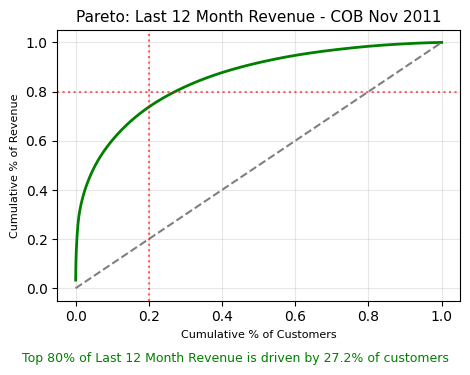

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 0. Create the filtered DataFrame (Focusing on current year)
df_ltm = df_B2B_customer_segmentation[df_B2B_customer_segmentation['current_year'] == True]

# 1. Prepare data for Current Year Revenue (The "Right" graph logic)
df_ann = df_ltm.sort_values('ltm_revenue', ascending=False).reset_index(drop=True)
df_ann['cum_rev_pct'] = df_ann['ltm_revenue'].cumsum() / df_ann['ltm_revenue'].sum()
df_ann['cum_cust_pct'] = (df_ann.index + 1) / len(df_ann)

# 2. Plotting (Single Plot)
# plt.figure(figsize=(10, 6))
plt.figure(figsize=(4.8, 3.6))

# Plot the Pareto curve
plt.plot(df_ann['cum_cust_pct'], df_ann['cum_rev_pct'], color='green', lw=2, label='LTM Revenue')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--') # Line of equality

# Pareto Reference Lines (80/20)
plt.axhline(0.80, color='red', linestyle=':', alpha=0.6)
plt.axvline(0.20, color='red', linestyle=':', alpha=0.6)

# Labels and Title
plt.title('Pareto: Last 12 Month Revenue - COB Nov 2011', fontsize=11)
plt.xlabel('Cumulative % of Customers', fontsize=8)
plt.ylabel('Cumulative % of Revenue', fontsize=8)
plt.grid(True, alpha=0.3)

# Calculate calculation for the text label
top_80_ann = df_ann[df_ann['cum_rev_pct'] <= 0.80].shape[0] / len(df_ann)

# Add the summary text at the bottom
plt.figtext(0.5, -0.02, f"Top 80% of Last 12 Month Revenue is driven by {top_80_ann*100:.1f}% of customers", 
            ha="center", fontsize=9, color='green', 
            # bbox={"facecolor":"orange", "alpha":0.1, "pad":5}
            )

plt.tight_layout()
plt.show()

---
### Let's check lifecycle_segment, value_tier and trajectory

In [14]:
# 1 Are Cannot Lose Them customers actually high-value? They should be.
pd.crosstab(df_ltm['lifecycle_segment'], df_ltm['current_value_tier'])

import pandas as pd

# 1. Define the order
row_order = [
    'Champions', 'Champions Lower-Value', 'Loyal', 'Loyal Lower-Value', 
    'Cannot Lose Them', 'Cannot Lose Lower-Value', 'New / Promising', 
    'Frequent Low-Spend', 'About to Sleep', 'Needs Attention', 'At Risk', 
    'Lost High-Value', 'Hibernating / Lost'
]
col_order = ['Key Account', 'Core Account', 'Standard Account']

# 2. Create the crosstab
ct = pd.crosstab(
    df_ltm['lifecycle_segment'], 
    df_ltm['current_value_tier'], 
    margins=True, 
    margins_name='Total'
)

# 3. Reorder, Reset Index (to move label to the top row), and Clean up
ct = ct.reindex(index=row_order + ['Total'], columns=col_order)
ct = ct.rename(index={'Total': 'Total Customers'})
ct = ct.reset_index() 
ct = ct.rename(columns={'lifecycle_segment': 'Lifecycle Segment'})


# 4. Styling
styled_table = ct.style.hide(axis='index').set_table_styles([
    # HEADER: Line above and below, White background, Bold
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'left')
    ]},
    # DATA CELLS: No borders, No bold, Align right
    {'selector': 'td', 'props': [
        ('padding', '7px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    # Ensure the first column (Segments) is left-aligned and indented
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('padding-left', '25px')  # Indents the names like "Champions"
    ]},
    # TOTAL ROW: Line above it
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    # BOLD ONLY THE TOTAL ROW
    lambda x: ['font-weight: bold' if x.name == ct.index[-1] else '' for _ in x], 
    axis=1
).format(
    # Format numbers with commas, but ignore the first text column
    "{:,.0f}", subset=col_order
)

# Display
styled_table


Lifecycle Segment,Key Account,Core Account,Standard Account
Champions,729,192,0
Champions Lower-Value,0,137,0
Loyal,180,67,0
Loyal Lower-Value,0,60,0
Cannot Lose Them,121,73,0
Cannot Lose Lower-Value,0,72,37
New / Promising,8,63,269
Frequent Low-Spend,0,19,201
About to Sleep,48,276,0
Needs Attention,12,84,242


In [15]:
import pandas as pd

# 1. Define the order
row_order = [
    'Champions', 'Champions Lower-Value', 'Loyal', 'Loyal Lower-Value', 
    'Cannot Lose Them', 'Cannot Lose Lower-Value', 'New / Promising', 
    'Frequent Low-Spend', 'About to Sleep', 'Needs Attention', 'At Risk', 
    'Lost High-Value', 'Hibernating / Lost'
]
col_order = ['Key Account', 'Core Account', 'Standard Account']

# 2. Create the crosstab with MEAN aggregation
ct = pd.crosstab(
    index=df_ltm['lifecycle_segment'], 
    columns=df_ltm['current_value_tier'], 
    values=df_ltm['ltm_revenue'],  # <--- Use revenue for the values
    aggfunc='mean',                # <--- Change from count to mean
    margins=True, 
    margins_name='Total'
).fillna(0)                        # Replace any empty combos with 0

# 3. Reorder, Reset Index, and Clean up labels
# We use .reindex to ensure our specific order is kept
ct = ct.reindex(index=row_order + ['Total'], columns=col_order + ['Total'])

# Rename the "Total" row to be descriptive
ct = ct.rename(index={'Total': 'Average (All Segments)'})
ct = ct.reset_index() 
ct = ct.rename(columns={'lifecycle_segment': 'Lifecycle Segment'})

# 4. Styling
# Note: I changed the format to "${:,.0f}" since it is now revenue/spend
styled_table = ct.style.hide(axis='index').set_table_styles([
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'left')
    ]},
    {'selector': 'td', 'props': [
        ('padding', '6px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('padding-left', '25px')
    ]},
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    lambda x: ['font-weight: bold' if x.name == ct.index[-1] else '' for _ in x], 
    axis=1
).format(
    "£{:,.0f}", subset=col_order + ['Total'] # Added '£' and included the Total column
)

# Display
styled_table

Lifecycle Segment,Key Account,Core Account,Standard Account,Total
Champions,"£7,360","£1,210",£0,"£6,078"
Champions Lower-Value,£0,£734,£0,£734
Loyal,"£3,147","£1,214",£0,"£2,622"
Loyal Lower-Value,£0,£732,£0,£732
Cannot Lose Them,"£3,313","£1,162",£0,"£2,504"
Cannot Lose Lower-Value,£0,£697,£323,£570
New / Promising,"£2,609",£715,£245,£387
Frequent Low-Spend,£0,£484,£316,£331
About to Sleep,"£2,538",£832,£0,"£1,085"
Needs Attention,"£2,343",£771,£250,£454


Lifecycle Segment,Key Account,Core Account,Standard Account,Total
Champions,"£7,360","£1,210",£0,"£6,078"
Champions Lower-Value,£0,£734,£0,£734
Loyal,"£3,147","£1,214",£0,"£2,622"
Loyal Lower-Value,£0,£732,£0,£732
Cannot Lose Them,"£3,313","£1,162",£0,"£2,504"
Cannot Lose Lower-Value,£0,£697,£323,£570
New / Promising,"£2,609",£715,£245,£387
Frequent Low-Spend,£0,£484,£316,£331
About to Sleep,"£2,538",£832,£0,"£1,085"
Needs Attention,"£2,343",£771,£250,£454

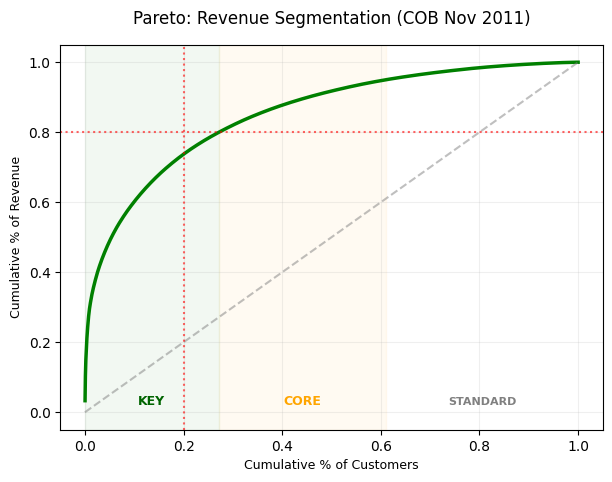

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# --- 1. Prepare Data (Code A logic) ---
df_ltm = df_B2B_customer_segmentation[df_B2B_customer_segmentation['current_year'] == True]

# Prepare Pareto Data
df_ann = df_ltm.sort_values('ltm_revenue', ascending=False).reset_index(drop=True)
df_ann['current_cum_rev_pct'] = df_ann['ltm_revenue'].cumsum() / df_ann['ltm_revenue'].sum()
df_ann['current_cum_cust_pct'] = (df_ann.index + 1) / len(df_ann)

# Calculate Tier Breakpoints for the X-Axis Labels
# We find the furthest point (max cumulative %) for each tier
key_max = df_ann[df_ann['current_value_tier'] == 'Key Account']['current_cum_cust_pct'].max()
core_max = df_ann[df_ann['current_value_tier'] == 'Core Account']['current_cum_cust_pct'].max()

# --- 2. Create the Pareto Plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(df_ann['current_cum_cust_pct'], df_ann['current_cum_rev_pct'], color='green', lw=2.5)
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.5)

# Reference Lines
ax.axhline(0.80, color='red', linestyle=':', alpha=0.6)
ax.axvline(0.20, color='red', linestyle=':', alpha=0.6)

# ADDING TIER LABELS ABOVE X-AXIS
# Key Accounts (from 0 to key_max)
ax.text(key_max/2, 0.02, 'KEY', color='darkgreen', fontsize=9, fontweight='bold', ha='center')
# Core Accounts (from key_max to core_max)
ax.text(key_max + (core_max - key_max)/2, 0.02, 'CORE', color='orange', fontsize=9, fontweight='bold', ha='center')
# Standard Accounts (from core_max to 1.0)
ax.text(core_max + (1 - core_max)/2, 0.02, 'STANDARD', color='grey', fontsize=8, fontweight='bold', ha='center')

# Shading the tiers (Optional but helpful)
ax.axvspan(0, key_max, color='green', alpha=0.05)
ax.axvspan(key_max, core_max, color='orange', alpha=0.05)

ax.set_title('Pareto: Revenue Segmentation (COB Nov 2011)', fontsize=12, pad=15)
ax.set_xlabel('Cumulative % of Customers', fontsize=9)
ax.set_ylabel('Cumulative % of Revenue', fontsize=9)
ax.grid(True, alpha=0.2)

# Save the plot to a temporary variable to display later
plt.close(fig) 

# --- 3. Create the Styled Table (Code B logic) ---
row_order = [
    'Champions', 'Champions Lower-Value', 'Loyal', 'Loyal Lower-Value', 
    'Cannot Lose Them', 'Cannot Lose Lower-Value', 'New / Promising', 
    'Frequent Low-Spend', 'About to Sleep', 'Needs Attention', 'At Risk', 
    'Lost High-Value', 'Hibernating / Lost'
]
col_order = ['Key Account', 'Core Account', 'Standard Account']

ct = pd.crosstab(
    index=df_ltm['lifecycle_segment'], 
    columns=df_ltm['current_value_tier'], 
    values=df_ltm['ltm_revenue'], 
    aggfunc='mean', 
    margins=True, margins_name='Total'
).fillna(0)

ct = ct.reindex(index=row_order + ['Total'], columns=col_order + ['Total'])
ct = ct.rename(index={'Total': 'All Segments Average'}).reset_index()
ct = ct.rename(columns={'lifecycle_segment': 'Lifecycle Segment'})

styled_table = ct.style.hide(axis='index').set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', 'white'), ('color', 'black'), ('font-weight', 'bold'), ('border-bottom', '1px solid #444'), ('padding', '8px'),('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'right'), ('font-size', '11px')]},
    {'selector': 'td:first-child', 'props': [('text-align', 'left'), ('padding-left', '17px')]},
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444'), ('font-weight', 'bold')]}
]).format("£{:,.0f}", subset=col_order + ['Total'])

# --- 4. Display side-by-side using HTML/CSS ---
# This helper converts the matplotlib figure to an HTML image tag
import base64
from io import BytesIO

buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches='tight')
data = base64.b64encode(buf.getbuffer()).decode("ascii")
img_html = f'<img src="data:image/png;base64,{data}" style="width:100%; max-width:600px;">'

# Combine Plot HTML and Table HTML into a 2-column layout
display(HTML(f"""
    <div style="display: flex; align-items: flex-start;">
        <div style="flex: 1; padding-right: 20px;">
            {img_html}
            <p style="color: green; font-size: 16px; text-align: center;">
                Top 80% of Revenue is driven by {top_80_ann*100:.1f}% of customers
            </p>
        </div>
        <div style="flex: 1;">
            <h2 style="text-align: center; ">Average Spend per Segment & Tier</h2>
            {styled_table.to_html()}
        </div>
    </div>
"""))

In [17]:
# 1 Are Cannot Lose Them customers actually high-value? They should be.
pd.crosstab(df_ltm['lifecycle_segment'], df_ltm['current_value_tier'])

import pandas as pd

# 1. Define the order
row_order = [
    'Champions', 'Champions Lower-Value', 'Loyal', 'Loyal Lower-Value', 
    'Cannot Lose Them', 'Cannot Lose Lower-Value', 'New / Promising', 
    'Frequent Low-Spend', 'About to Sleep', 'Needs Attention', 'At Risk', 
    'Lost High-Value', 'Hibernating / Lost'
]
col_order = ['Key Account', 'Core Account', 'Standard Account']

# 2. Create the crosstab
ct = pd.crosstab(
    df_ltm['lifecycle_segment'], 
    df_ltm['current_value_tier'], 
    margins=True, 
    margins_name='Total'
)

# 3. Reorder, Reset Index (to move label to the top row), and Clean up
ct = ct.reindex(index=row_order + ['Total'], columns=col_order)
ct = ct.rename(index={'Total': 'Total Customers'})
ct = ct.reset_index() 
ct = ct.rename(columns={'lifecycle_segment': 'Lifecycle Segment'})


# 4. Styling
styled_table = ct.style.hide(axis='index').set_table_styles([
    # HEADER: Line above and below, White background, Bold
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'left')
    ]},
    # DATA CELLS: No borders, No bold, Align right
    {'selector': 'td', 'props': [
        ('padding', '7px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    # Ensure the first column (Segments) is left-aligned and indented
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('padding-left', '25px')  # Indents the names like "Champions"
    ]},
    # TOTAL ROW: Line above it
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    # BOLD ONLY THE TOTAL ROW
    lambda x: ['font-weight: bold' if x.name == ct.index[-1] else '' for _ in x], 
    axis=1
).format(
    # Format numbers with commas, but ignore the first text column
    "{:,.0f}", subset=col_order
)

# Display
styled_table


Lifecycle Segment,Key Account,Core Account,Standard Account
Champions,729,192,0
Champions Lower-Value,0,137,0
Loyal,180,67,0
Loyal Lower-Value,0,60,0
Cannot Lose Them,121,73,0
Cannot Lose Lower-Value,0,72,37
New / Promising,8,63,269
Frequent Low-Spend,0,19,201
About to Sleep,48,276,0
Needs Attention,12,84,242


In [18]:
import pandas as pd

# 1. Define the order
row_order = [
    'Champions', 'Champions Lower-Value', 'Loyal', 'Loyal Lower-Value', 
    'Cannot Lose Them', 'Cannot Lose Lower-Value', 'New / Promising', 
    'Frequent Low-Spend', 'About to Sleep', 'Needs Attention', 'At Risk', 
    'Lost High-Value', 'Hibernating / Lost'
]
col_order = ['Growing', 'Stable', 'Declining', 'Insufficient data']

# 2. Create the crosstab
ct = pd.crosstab(
    df_ltm['lifecycle_segment'], 
    df_ltm['historical_trajectory'], 
    margins=True, 
    margins_name='Total'
)

# 3. Reorder, Reset Index (to move label to the top row), and Clean up
ct = ct.reindex(index=row_order + ['Total'], columns=col_order)
ct = ct.rename(index={'Total': 'Total Trajectory'})
ct = ct.reset_index() 
ct = ct.rename(columns={'lifecycle_segment': 'Lifecycle Segment'})


# 4. Styling
styled_table = ct.style.hide(axis='index').set_table_styles([
    # HEADER: Line above and below, White background, Bold
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'left')
    ]},
    # DATA CELLS: No borders, No bold, Align right
    {'selector': 'td', 'props': [
        ('padding', '7px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    # Ensure the first column (Segments) is left-aligned and indented
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('padding-left', '25px')  # Indents the names like "Champions"
    ]},
    # TOTAL ROW: Line above it
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    # BOLD ONLY THE TOTAL ROW
    lambda x: ['font-weight: bold' if x.name == ct.index[-1] else '' for _ in x], 
    axis=1
).format(
    # Format numbers with commas, but ignore the first text column
    "{:,.0f}", subset=col_order
)

# Display
styled_table

Lifecycle Segment,Growing,Stable,Declining,Insufficient data
Champions,175,512,135,99
Champions Lower-Value,22,54,26,35
Loyal,36,134,49,28
Loyal Lower-Value,7,27,17,9
Cannot Lose Them,38,81,46,29
Cannot Lose Lower-Value,10,38,33,28
New / Promising,4,41,32,263
Frequent Low-Spend,16,40,61,103
About to Sleep,38,102,55,129
Needs Attention,9,40,51,238


In [19]:
import pandas as pd

# 1. Define the order
row_order = [
    'Champions', 'Champions Lower-Value', 'Loyal', 'Loyal Lower-Value', 
    'Cannot Lose Them', 'Cannot Lose Lower-Value', 'New / Promising', 
    'Frequent Low-Spend', 'About to Sleep', 'Needs Attention', 'At Risk', 
    'Lost High-Value', 'Hibernating / Lost'
]
col_order = ['Growing', 'Stable', 'Declining', 'Opportunity to Grow', 'Slipping to Decline', 'Insufficient data']

# 2. Create the crosstab
ct = pd.crosstab(
    df_ltm['lifecycle_segment'], 
    df_ltm['trajectory_opportunity'], 
    margins=True, 
    margins_name='Total'
)

# 3. Reorder, Reset Index (to move label to the top row), and Clean up
ct = ct.reindex(index=row_order + ['Total'], columns=col_order)
ct = ct.rename(index={'Total': 'Total Trajectory'})
ct = ct.reset_index() 
ct = ct.rename(columns={'lifecycle_segment': 'Lifecycle Segment'})


# 4. Styling
styled_table = ct.style.hide(axis='index').set_table_styles([
    # HEADER: Line above and below, White background, Bold
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'left')
    ]},
    # DATA CELLS: No borders, No bold, Align right
    {'selector': 'td', 'props': [
        ('padding', '7px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    # Ensure the first column (Segments) is left-aligned and indented
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('padding-left', '25px')  # Indents the names like "Champions"
    ]},
    # TOTAL ROW: Line above it
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    # BOLD ONLY THE TOTAL ROW
    lambda x: ['font-weight: bold' if x.name == ct.index[-1] else '' for _ in x], 
    axis=1
).format(
    # Format numbers with commas, but ignore the first text column
    "{:,.0f}", subset=col_order
)

# Display
styled_table

Lifecycle Segment,Growing,Stable,Declining,Opportunity to Grow,Slipping to Decline,Insufficient data
Champions,175,393,135,66,53,99
Champions Lower-Value,22,42,26,8,4,35
Loyal,36,101,49,16,17,28
Loyal Lower-Value,7,19,17,3,5,9
Cannot Lose Them,38,53,46,13,15,29
Cannot Lose Lower-Value,10,24,33,8,6,28
New / Promising,4,24,32,4,13,263
Frequent Low-Spend,16,29,61,6,5,103
About to Sleep,38,71,55,14,17,129
Needs Attention,9,30,51,4,6,238


---
### Isolate About to Sleep Grow

In [20]:
# check the edge case active months 3 that it is not noise
sleep_grow = df_ltm[(df_ltm['lifecycle_segment']=='About to Sleep') & 
                            (df_ltm['historical_trajectory']=='Growing') & 
                            (df_ltm['n_active_months']==3)]
print(sleep_grow[['ltm_revenue', 'ltm_n_invoices', 'ltm_recency_days', 
                        'hist_rev_slope', 'hist_rev_slope_pct', 'n_active_months', 'ltm_n_active_months']].describe())

       ltm_revenue  ltm_n_invoices  ltm_recency_days  hist_rev_slope  \
count    18.000000            18.0              18.0       18.000000   
mean    756.845556        2.333333         33.333333        9.494867   
std     206.285815        0.485071          21.54339        7.583490   
min     503.760000             2.0               1.0        2.237610   
25%     624.205000             2.0              13.0        3.809358   
50%     705.655000             2.0              34.0        5.295784   
75%     832.827500             3.0             51.75       16.134742   
max    1186.350000             3.0              67.0       23.210110   

       hist_rev_slope_pct  n_active_months  ltm_n_active_months  
count           18.000000             18.0                 18.0  
mean             0.117112              3.0             2.222222  
std              0.065071              0.0             0.427793  
min              0.045497              3.0                  2.0  
25%              0.06

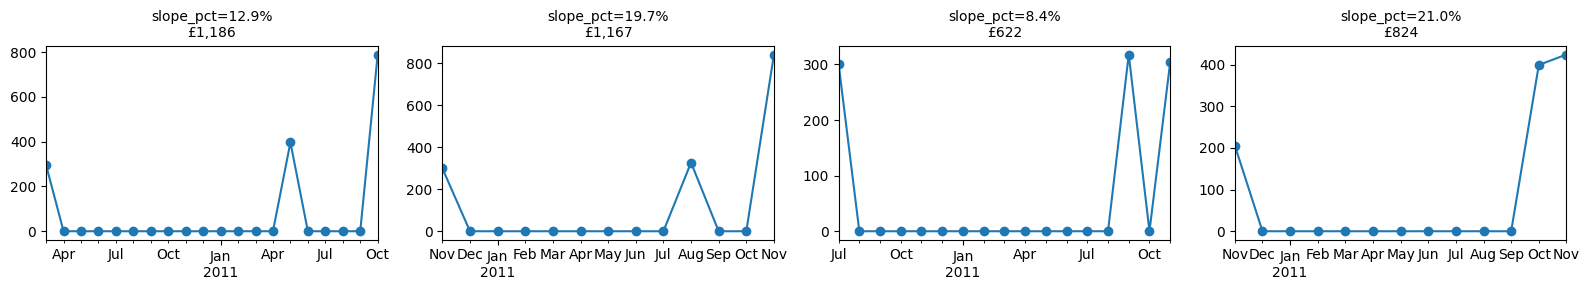

In [21]:
import matplotlib.pyplot as plt

# Pull 4 random growing Sleepers (edge case) and plot their monthly trajectories
sample = sleep_grow.sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df_B2B_customer_orders[df_B2B_customer_orders['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['hist_rev_slope_pct']*100:.1f}%\n£{row['ltm_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

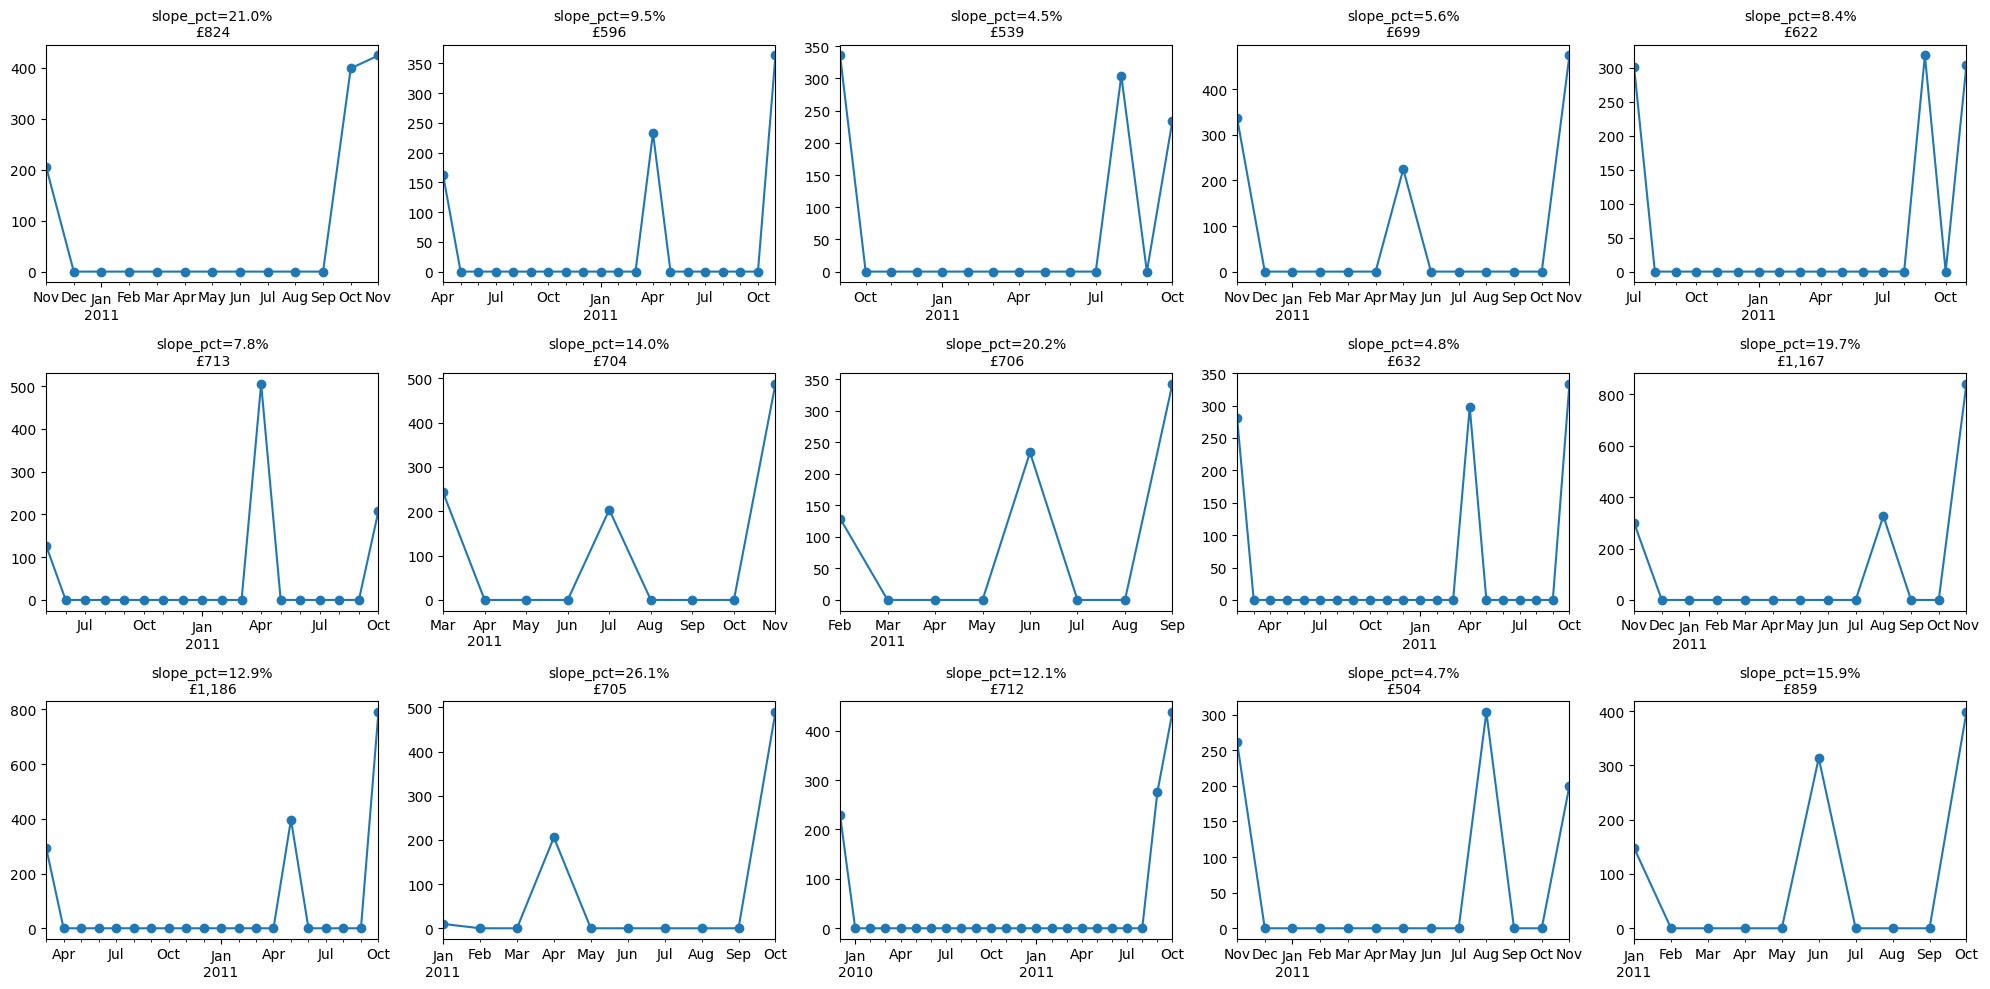

In [22]:
purchase_pattern =   df_ltm[(df_ltm['lifecycle_segment']=='About to Sleep') & 
                            (df_ltm['historical_trajectory']=='Growing') & 
                            (df_ltm['n_active_months']==3)]

import matplotlib.pyplot as plt

sample = purchase_pattern.sample(15, random_state=82)
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    monthly = (df_B2B_customer_orders[df_B2B_customer_orders['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['hist_rev_slope_pct']*100:.1f}%\n£{row['ltm_revenue']:,.0f}",
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

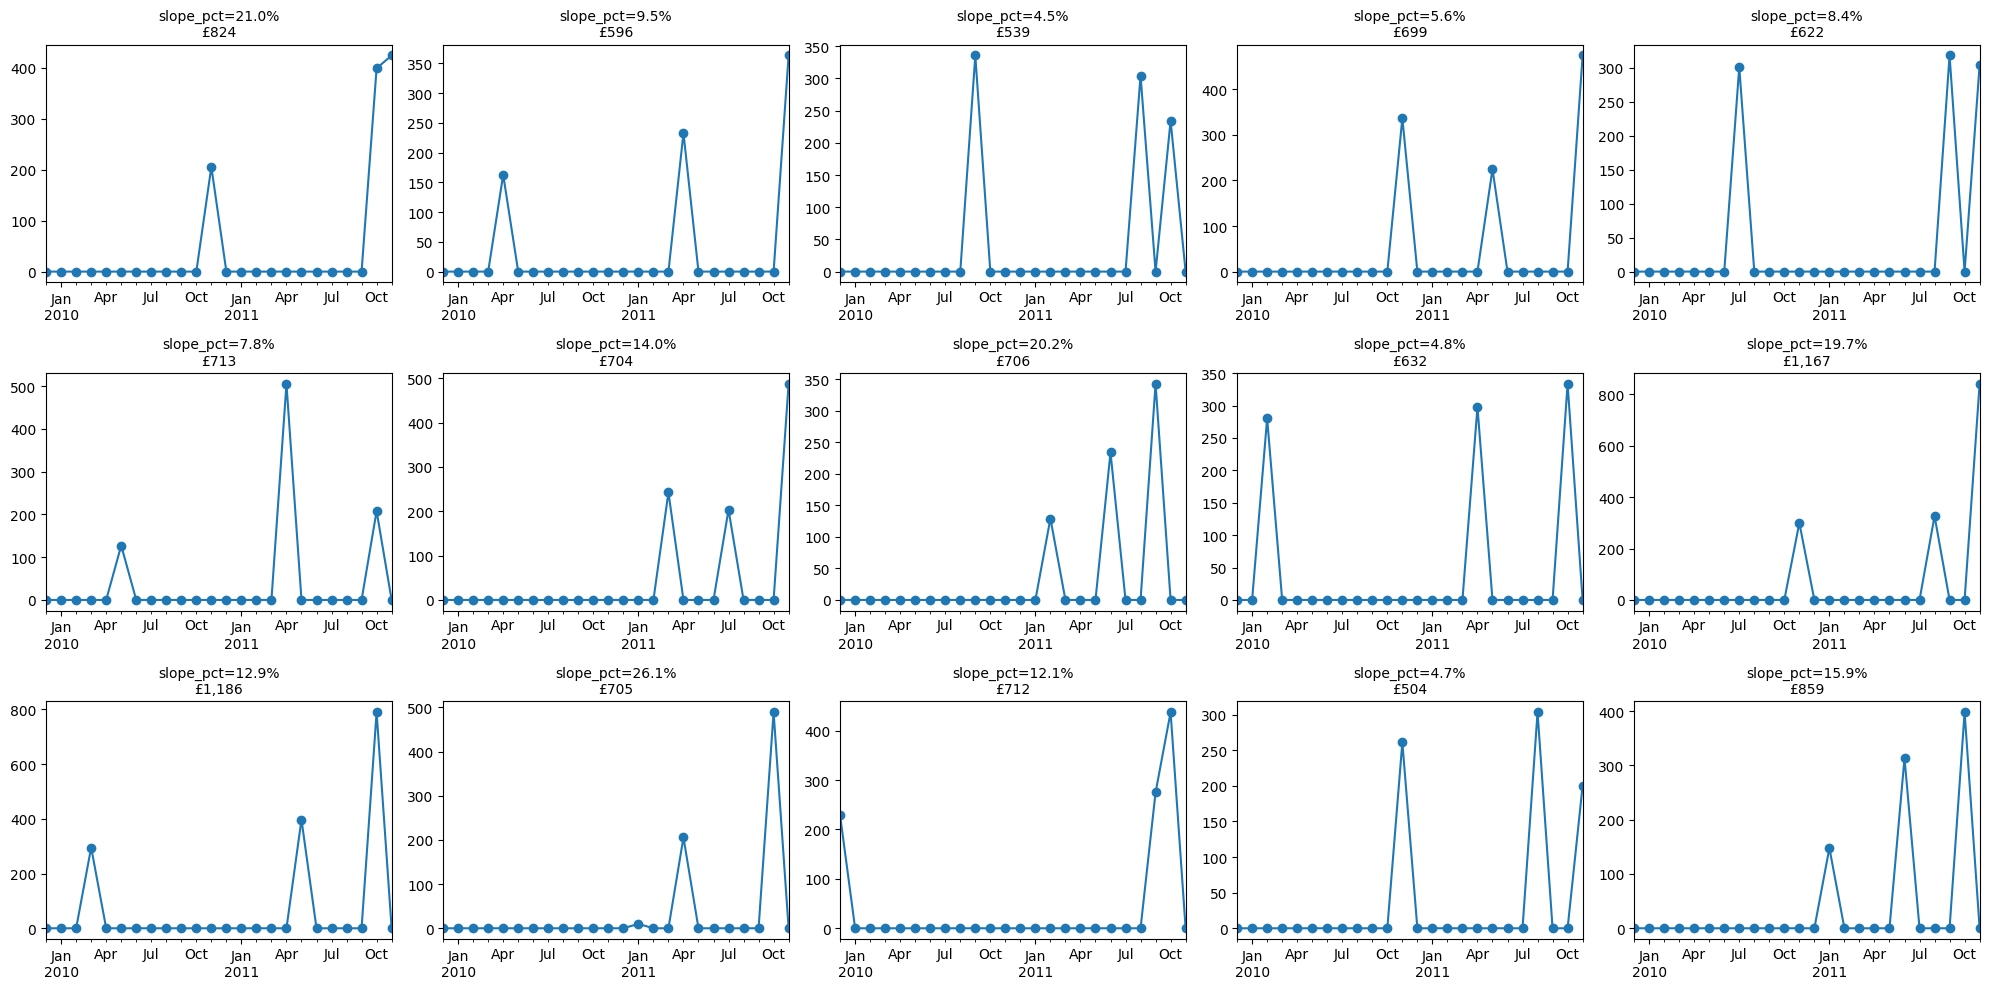

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the "Master" date range (Month-End frequency)
# This creates a list of all months from Dec 2009 to Nov 2011
full_range = pd.date_range(start='2009-12-01', end='2011-11-30', freq='ME')

sample = purchase_pattern.sample(15, random_state=82)
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    # Get the raw monthly sums
    monthly = (df_B2B_customer_orders[df_B2B_customer_orders['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    
    # 2. FORCE zeros into the missing months
    # This ensures the line starts at the beginning and ends at the end of your timeframe
    monthly = monthly.reindex(full_range, fill_value=0)
    
    # 3. Plot
    monthly.plot(ax=ax, marker='o')
    
    # 4. Force the x-axis view to stay consistent
    ax.set_xlim(full_range.min(), full_range.max())
    
    ax.set_title(f"slope_pct={row['hist_rev_slope_pct']*100:.1f}%\n£{row['ltm_revenue']:,.0f}",
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [24]:
# 3 The three-way matrix of populated personas. Note this is the first draft
pd.crosstab([df_ltm['lifecycle_segment'], df_ltm['current_value_tier']], df_ltm['trajectory_opportunity'])

trajectory_opportunity                      Declining  Growing  \
lifecycle_segment       current_value_tier                       
About to Sleep          Core Account               50       31   
                        Key Account                 5        7   
At Risk                 Core Account               37       20   
                        Key Account                 5       13   
                        Standard Account           37       11   
Cannot Lose Lower-Value Core Account               21        6   
                        Standard Account           12        4   
Cannot Lose Them        Core Account               19       10   
                        Key Account                27       28   
Champions               Core Account               39       36   
                        Key Account                96      139   
Champions Lower-Value   Core Account               26       22   
Frequent Low-Spend      Core Account                8        1   
                        Standard Account           53       15   
Hibernating / Lost      Core Account               24       17   
                        Standard Account          137       33   
Lost High-Value         Core Account                5        2   
                        Key Account                 3        3   
Loyal                   Core Account               19       10   
                        Key Account                30       26   
Loyal Lower-Value       Core Account               17        7   
Needs Attention         Core Account                6        4   
                        Key Account                 2        3   
                        Standard Account           43        2   
New / Promising         Core Account                5        2   
                        Key Account                 1        0   
                        Standard Account           26        2   

trajectory_opportunity                      Insufficient data  \
lifecycle_segment       current_value_tier                      
About to Sleep          Core Account                      117   
                        Key Account                        12   
At Risk                 Core Account                       78   
                        Key Account                         8   
                        Standard Account                   55   
Cannot Lose Lower-Value Core Account                       17   
                        Standard Account                   11   
Cannot Lose Them        Core Account                       16   
                        Key Account                        13   
Champions               Core Account                       41   
                        Key Account                        58   
Champions Lower-Value   Core Account                       35   
Frequent Low-Spend      Core Account                        6   
                        Standard Account                   97   
Hibernating / Lost      Core Account                      105   
                        Standard Account                  548   
Lost High-Value         Core Account                       31   
                        Key Account                        18   
Loyal                   Core Account                       12   
                        Key Account                        16   
Loyal Lower-Value       Core Account                        9   
Needs Attention         Core Account                       55   
                        Key Account                         6   
                        Standard Account                  177   
New / Promising         Core Account                       45   
                        Key Account                         6   
                        Standard Account                  212   

trajectory_opportunity                      Opportunity to Grow  \
lifecycle_segment       current_value_tier                        
About to Sleep          Core Account                          9  

In [25]:
df_ltm['ltm_n_active_months'].value_counts()

ltm_n_active_months
1     1700
2      893
3      515
4      367
5      246
6      157
7      112
8       79
9       63
10      55
12      54
11      45
Name: count, dtype: Int64

---
### Historical Value and status

In [26]:
pd.crosstab([df_B2B_customer_segmentation['customer_status_yoy'], df_B2B_customer_segmentation['historical_trajectory']], df_B2B_customer_segmentation['historical_value_tier'])

historical_value_tier                      Core Account  Key Account  \
customer_status_yoy historical_trajectory                              
Churned             Declining                        43           13   
                    Growing                          39            5   
                    Insufficient data               235           31   
                    Stable                           26            7   
Existing            Declining                       350          268   
                    Growing                         177          177   
                    Insufficient data               149           17   
                    Stable                          403          751   
New                 Declining                        38           18   
                    Growing                          39           14   
                    Insufficient data               355           51   
                    Stable                           27           18   

historical_value_tier                      Standard Account  
customer_status_yoy historical_trajectory                    
Churned             Declining                            11  
                    Growing                               8  
                    Insufficient data                  1106  
                    Stable                                6  
Existing            Declining                            63  
                    Growing                              39  
                    Insufficient data                   235  
                    Stable                               70  
New                 Declining                            16  
                    Growing                               8  
                    Insufficient data                  1002  
                    Stable                                6

In [27]:
pd.crosstab(df_B2B_customer_segmentation['purchase_behaviour'], df_B2B_customer_segmentation['historical_value_tier'])

historical_value_tier,Core Account,Key Account,Standard Account
purchase_behaviour,,,
H1 Purchase,47,9,48
H2 Purchase,186,42,109
New-Year Purchase,6,2,18
New-Year Summer Purchase,32,7,20
One-Time Purchase,185,16,1673
Spring-Season Purchase,4,0,14
Spring-Summer Purchase,84,15,60
Spring-Winter Purchase,125,18,39
Summer-Season Purchase,18,0,20


In [62]:
import pandas as pd

# 1. Create the adjusted Value Tier column based on your logic
def adjust_tier(row):
    if row['historical_value_tier'] == 'Standard Account' and row['purchase_behaviour'] == 'One-Time Purchase':
        return 'One-Time Purchase'
    return row['historical_value_tier']

df_B2B_customer_segmentation['adjusted_tier'] = df_B2B_customer_segmentation.apply(adjust_tier, axis=1)

# 2. Run the crosstab using the new 'adjusted_tier' column
ct_df = pd.crosstab(
    [df_B2B_customer_segmentation['customer_status_yoy'], df_B2B_customer_segmentation['historical_trajectory']], 
    df_B2B_customer_segmentation['adjusted_tier']
)

# 3. Simplify the Row Labels (Indices)
df_clean = ct_df.reset_index()

def simplify_segments(row):
    status = row['customer_status_yoy']
    trajectory = row['historical_trajectory']
    
    if status == 'Churned': return 'Churned Customers'
    if status == 'New': return 'New Customers'
    if status == 'Existing' and trajectory in ['Stable', 'Insufficient data']:
        return 'Existing Customers'
    return f"{status} {trajectory}"

df_clean['Segment'] = df_clean.apply(simplify_segments, axis=1)

# 4. Group by the new simplified segments and sum the values
final_table = df_clean.groupby('Segment').sum(numeric_only=True)

# 5. REORDER COLUMNS: Key -> Core -> Standard -> One-Time Purchase
col_order = ['Key Account', 'Core Account', 'Standard Account', 'One-Time Purchase']
# We use a list comprehension to ensure we only select columns that actually exist in the data
final_table = final_table[[c for c in col_order if c in final_table.columns]]

# 6. REORDER ROWS for logical flow
row_order = ['New Customers', 'Existing Customers', 'Existing Growing', 'Existing Declining', 'Churned Customers']
final_table = final_table.reindex([r for r in row_order if r in final_table.index])

final_table

adjusted_tier,Key Account,Core Account,Standard Account,One-Time Purchase
Segment,,,,
New Customers,101,459,236,796
Existing Customers,768,552,301,4
Existing Growing,177,177,39,0
Existing Declining,268,350,63,0
Churned Customers,56,343,258,873


In [29]:
import pandas as pd

# 1. Define the order
row_order = ['Key Account', 'Core Account', 'Standard Account']
col_order = ['Key Account', 'Core Account', 'Standard Account']

# 2. Create the crosstab
ct = pd.crosstab(df_B2B_customer_segmentation['current_value_tier'], [df_B2B_customer_segmentation['customer_status_yoy'], df_B2B_customer_segmentation['historical_value_tier']],
    margins=True, 
    margins_name='Total'
)

# 3. Reorder, Reset Index (to move label to the top row), and Clean up
ct = ct.reindex(index=row_order + ['Total'], columns=col_order)
ct = ct.rename(index={'Total': 'Total Customers'})
ct = ct.reset_index() 
ct = ct.rename(columns={'current_value_tier': 'Customer Value Tier'})


# 4. Styling
styled_table = ct.style.hide(axis='index').set_table_styles([
    # HEADER: Line above and below, White background, Bold
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'left')
    ]},
    # DATA CELLS: No borders, No bold, Align right
    {'selector': 'td', 'props': [
        ('padding', '7px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    # Ensure the first column (Segments) is left-aligned and indented
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('padding-left', '25px')  # Indents the names like "Champions"
    ]},
    # TOTAL ROW: Line above it
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    # BOLD ONLY THE TOTAL ROW
    lambda x: ['font-weight: bold' if x.name == ct.index[-1] else '' for _ in x], 
    axis=1
).format(
    # Format numbers with commas, but ignore the first text column
    "{:,.0f}", subset=col_order
)

# Display
styled_table




Customer Value Tier,Key Account,Core Account,Standard Account
Key Account,nan,nan,nan
Core Account,nan,nan,nan
Standard Account,nan,nan,nan
Total Customers,nan,nan,nan


In [30]:
pd.crosstab([df_B2B_customer_segmentation['customer_status_yoy'], df_B2B_customer_segmentation['current_value_tier']], df_B2B_customer_segmentation['historical_value_tier'])


historical_value_tier                   Core Account  Key Account  \
customer_status_yoy current_value_tier                              
Existing            Core Account                 607          270   
                    Key Account                   43          909   
                    Standard Account             429           34   
New                 Core Account                 344            1   
                    Key Account                  112          100   
                    Standard Account               3            0   

historical_value_tier                   Standard Account  
customer_status_yoy current_value_tier                    
Existing            Core Account                       9  
                    Key Account                        0  
                    Standard Account                 398  
New                 Core Account                     221  
                    Key Account                        0  
                    Standard Account                 806

In [31]:
# 1. Migration matrix — the real upgrade/downgrade picture
existing = df_B2B_customer_segmentation[
    df_B2B_customer_segmentation['customer_status_yoy'] == 'Existing'
]
migration = pd.crosstab(
    existing['historical_value_tier'],
    existing['current_value_tier'],
    margins=True
)

# 2. Win-back targeting — churned customers by what they used to be worth
df_B2B_customer_segmentation.query("customer_status_yoy == 'Churned'") \
    ['historical_value_tier'].value_counts()

# 3. Onboarding/nurture priority — new customers by where they've landed
# df_B2B_customer_segmentation.query("customer_status_yoy == 'New'") \
#     ['current_value_tier'].value_counts()

migration

current_value_tier,Core Account,Key Account,Standard Account,All
historical_value_tier,,,,
Core Account,607,43,429,1079
Key Account,270,909,34,1213
Standard Account,9,0,398,407
All,886,952,861,2699


In [32]:
import pandas as pd

# 1. Generate the three components
# Existing (Migration Matrix)
existing = df_B2B_customer_segmentation[df_B2B_customer_segmentation['customer_status_yoy'] == 'Existing']
migration = pd.crosstab(
    existing['historical_value_tier'], 
    existing['current_value_tier']
)

# Churn (Counts by where they used to be)
churn = df_B2B_customer_segmentation.query("customer_status_yoy == 'Churned'") \
    ['historical_value_tier'].value_counts().rename('Churned')

# New (Counts by where they landed)
new = df_B2B_customer_segmentation.query("customer_status_yoy == 'New'") \
    ['current_value_tier'].value_counts().rename('New')

# 2. Combine them into one "Master Migration" table
# First, add the Churned column to the existing matrix
full_table = migration.join(churn, how='outer').fillna(0)

# Second, add the New row (transposed to match columns)
new_row = pd.DataFrame([new], index=['New'])
full_table = pd.concat([full_table, new_row]).fillna(0).astype(int)

# 3. Add Multi-headers for 'Existing', 'Churn', and 'New' logic
# (Optional: Rename columns/index for better presentation)
full_table.index.name = 'Historical Tier'
full_table.columns.name = 'Current Tier'

print(full_table)

Current Tier      Core Account  Key Account  Standard Account  Churned
Historical Tier                                                       
Core Account               607           43               429      343
Key Account                270          909                34       56
Standard Account             9            0               398     1131
New                        566          212               809        0


In [60]:
import pandas as pd
import numpy as np

# 1. Setup tiers and data
tier_order = ['Key Account', 'Core Account', 'Standard Account']

# Existing (Migration Matrix)
existing = df_B2B_customer_segmentation[df_B2B_customer_segmentation['customer_status_yoy'] == 'Existing']
migration = pd.crosstab(
    existing['historical_value_tier'], 
    existing['current_value_tier']
)

# Churn (Counts by where they used to be)
churn = df_B2B_customer_segmentation.query("customer_status_yoy == 'Churned'") \
    ['historical_value_tier'].value_counts()

# New (Counts by where they landed)
new = df_B2B_customer_segmentation.query("customer_status_yoy == 'New'") \
    ['current_value_tier'].value_counts()

# 2. Build the Master Table
# Join migration + churn (columns)
full_table = migration.reindex(index=tier_order, columns=tier_order).fillna(0)
full_table['Churned'] = churn

# Add the 'New' row
new_row = pd.DataFrame([new], index=['New Customers'], columns=tier_order)
full_table = pd.concat([full_table, new_row]).fillna(0)

# 3. Calculate Totals manually
# full_table['Total'] = full_table.sum(axis=1)
total_row = full_table.sum(axis=0)
total_row.name = 'Total'
full_table = pd.concat([full_table, pd.DataFrame([total_row])])

# Clean up types
full_table = full_table.astype(int)

# 4. Preparation for Styling
# Reset index to make 'Historical Tier' a column so we can align it left
plot_df = full_table.reset_index().rename(columns={'index': 'Current Year Segment →'})
column_list = [col for col in plot_df.columns if col != 'Current Year Segment →']

# 5. Styling
styled_table = plot_df.style.hide(axis='index').set_table_styles([
    # HEADER styling
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'bold'),
        ('border-top', '2px solid #444'),
        ('border-bottom', '1px solid #444'),
        ('padding', '12px'),
        ('text-align', 'right')
    ]},
    # Generic cell styling
    {'selector': 'td', 'props': [
        ('padding', '8px'),
        ('border', 'none'),
        ('text-align', 'right')
    ]},
    # Left-align the first column
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'),
        ('font-weight', 'bold'),
        ('padding-left', '25px')  # Indents the names like "Key Account"
        # ('background-color', '#f9f9f9')
    ]},
    # Top border for the Total row (last row)
    {'selector': 'tr:last-child', 'props': [('border-top', '1px solid #444')]}
]).apply(
    # Bold the Total row and Total column
    lambda x: ['font-weight: bold' if (x.name == plot_df.index[-1] or col == 'Total') else '' for col in plot_df.columns],
    axis=1
).format("{:,.0f}", subset=column_list)

# Display
styled_table


Current Year Segment →,Key Account,Core Account,Standard Account,Churned
Key Account,909,270,34,56
Core Account,43,607,429,343
Standard Account,0,9,398,"1,131"
New Customers,212,566,809,0
Total,"1,164","1,452","1,670","1,530"


In [61]:
import pandas as pd
import numpy as np

# 1. Setup tiers and data
tier_order = ['Key Account', 'Core Account', 'Standard Account']
tier_rank = {tier: i for i, tier in enumerate(reversed(tier_order), 1)}

# --- Data Preparation ---
existing = df_B2B_customer_segmentation[df_B2B_customer_segmentation['customer_status_yoy'] == 'Existing']
migration = pd.crosstab(existing['historical_value_tier'], existing['current_value_tier'])

churn = df_B2B_customer_segmentation.query("customer_status_yoy == 'Churned'")['historical_value_tier'].value_counts()
new = df_B2B_customer_segmentation.query("customer_status_yoy == 'New'")['current_value_tier'].value_counts()

# Build the Table
full_table = migration.reindex(index=tier_order, columns=tier_order).fillna(0)
full_table['Churned'] = churn

new_row = pd.DataFrame([new], index=['New Customers'], columns=tier_order)
full_table = pd.concat([full_table, new_row]).fillna(0)

# Add "Total Customers" row
total_row = full_table.sum(axis=0)
total_row.name = 'Total Customers'
full_table = pd.concat([full_table, pd.DataFrame([total_row])]).fillna(0).astype(int)

# 2. Preparation for Styling
plot_df = full_table.reset_index().rename(columns={'index': 'Current Year Segment →'})
data_cols = [c for c in plot_df.columns if c != 'Current Year Segment →']

# --- Logic for HTML Arrows with Fixed-Width Slot ---
def format_cell_with_arrows(row_label, col_label, val):
    arrow = ""
    color = ""
    
    # 1. New Customers Row (All Up)
    if row_label == 'New Customers' and col_label in tier_order and val > 0:
        arrow, color = "⬆", "green"
    
    # 2. Churned Column (All Down)
    elif col_label == 'Churned' and row_label in tier_order and val > 0:
        arrow, color = "⬇", "#d9534f"
    
    # 3. Migration Matrix (Upgrade/Downgrade)
    elif row_label in tier_order and col_label in tier_order and row_label != col_label and val > 0:
        if tier_rank[col_label] > tier_rank[row_label]:
            arrow, color = "⬆", "green"
        elif tier_rank[col_label] < tier_rank[row_label]:
            arrow, color = "⬇", "#d9534f"

    # Create the Arrow Slot: Fixed width ensures numbers stay aligned
    # display: inline-block makes the width property work
    arrow_html = f"<span style='display: inline-block; width: 15px; text-align: left; margin-left: 5px; color: {color};'>{arrow}</span>"
    
    return f"{val:,.0f}{arrow_html}"

# 3. Apply Styling
styled_table = plot_df.style.hide(axis='index').set_table_styles([
    {'selector': 'thead th', 'props': [
        ('background-color', 'white'), ('color', 'black'), ('font-weight', 'bold'),
        ('border-top', '2px solid #444'), ('border-bottom', '1px solid #444'),
        ('padding', '12px'), ('text-align', 'right')
    ]},
    {'selector': 'td', 'props': [
        ('padding', '8px'), ('border', 'none'), 
        ('text-align', 'right'), ('font-weight', 'normal'), ('color', 'black'),
        ('white-space', 'nowrap') # Prevents the arrow from wrapping to a new line
    ]},
    {'selector': 'td:first-child', 'props': [
        ('text-align', 'left'), ('font-weight', 'plain'), ('padding-left', '25px')
    ]},
    {'selector': 'tr:last-child td', 'props': [
        ('font-weight', 'bold'), ('border-top', '1px solid #444')
    ]}
])

# Use a more robust way to format to avoid duplicate-value lookup issues
for col in data_cols:
    styled_table = styled_table.format(
        lambda x, c=col, df=plot_df: format_cell_with_arrows(
            # We find the row label using the internal index of the styler
            df.iloc[np.where(df[c] == x)[0][0]]['Current Year Segment →'] if len(np.where(df[c] == x)[0]) > 0 else "", 
            c, x
        ),
        subset=[col]
    )

styled_table

Current Year Segment →,Key Account,Core Account,Standard Account,Churned
Key Account,909,270⬇,34⬇,56⬇
Core Account,43⬆,607,429⬇,343⬇
Standard Account,0,9⬆,398,"1,131⬇"
New Customers,212⬆,566⬆,809⬆,0
Total Customers,"1,164","1,452","1,670","1,530"


Plot Existing and New By Region, I mean key account by region

In [64]:
pd.crosstab(df_B2B_customer_segmentation['region'], df_B2B_customer_segmentation['customer_status_yoy'])

customer_status_yoy,Churned,Existing,New
region,,,
AMER,7,1,7
APAC,11,11,6
CHANNEL ISLANDS,4,7,2
EMEA,75,204,169
UK DOMESTIC,1431,2474,1406
UNSPECIFIED,2,2,2
